In [1]:
import sys
#akshare and xgboost
!{sys.executable} -m pip install -U akshare xgboost -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, linregress
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    log_loss,
)


In [3]:
# =========================
# 0. Parameter settings
# =========================
H = 5                    # future 5 bars
TH = 0.05            # threshold: 5%



In [4]:
# =========================
# 1. Load main continuous contract daily K-line data & handle time
# =========================
def load_main_csv(csv_path):

    df = pd.read_csv(csv_path)

    # 1) Build datetime index from `date`
    df["datetime"] = pd.to_datetime(df["date"])
    df = df.sort_values("datetime").set_index("datetime")

    # 2) Use adjusted OHLC columns (adj_*) and keep volume / hold as is
    data = pd.DataFrame(index=df.index)
    data["open"]   = df["adj_open"].astype(float)
    data["high"]   = df["adj_high"].astype(float)
    data["low"]    = df["adj_low"].astype(float)
    data["close"]  = df["adj_close"].astype(float)
    data["volume"] = df["volume"].astype(float)
    data["hold"]   = df["hold"].astype(float)
    return data

data = load_main_csv("TA.csv")
print(data.head())

                   open         high          low        close    volume  \
datetime                                                                   
2014-01-02  6674.572649  6674.572649  6592.998567  6611.126141  323978.0   
2014-01-03  6558.556177  6587.560295  6536.803089  6544.054118  173350.0   
2014-01-06  6534.990332  6536.803089  6467.918309  6476.982096  238492.0   
2014-01-07  6489.671397  6489.671397  6404.471801  6431.663161  221352.0   
2014-01-08  6424.412132  6458.854522  6413.535588  6438.914191  150578.0   

                hold  
datetime              
2014-01-02  403860.0  
2014-01-03  407484.0  
2014-01-06  422160.0  
2014-01-07  437950.0  
2014-01-08  427392.0  


In [5]:
# =========================
# 2. Load main continuous contract weekly K-line data & handle time
# =========================
def load_main_csv(csv_path):

    df = pd.read_csv(csv_path)

    # 1) Build datetime index from `date`
    df["datetime"] = pd.to_datetime(df["date"])
    df = df.sort_values("datetime").set_index("datetime")
    return df


data2 = load_main_csv("TA_weekly.csv")
print(data2.head())

                  date         open         high          low        close  \
datetime                                                                     
2014-01-03  2014-01-03  6674.572649  6674.572649  6536.803089  6544.054118   
2014-01-10  2014-01-10  6534.990332  6536.803089  6350.089079  6420.786617   
2014-01-17  2014-01-17  6426.224889  6440.726948  6275.766027  6377.371831   
2014-01-24  2014-01-24  6364.642546  6390.101116  6215.528063  6310.088467   
2014-01-31  2014-01-31  6297.359182  6311.906936  6197.343370  6237.349695   

               volume      hold  
datetime                         
2014-01-03   497328.0  407484.0  
2014-01-10  1140766.0  403938.0  
2014-01-17   995580.0  411552.0  
2014-01-24  1236006.0  436554.0  
2014-01-31   586102.0  406450.0  


In [6]:
print(data[['open', 'high', 'low', 'close', 'volume', 'hold']].isna().sum())

open      0
high      0
low       0
close     0
volume    0
hold      0
dtype: int64


In [7]:
# =========================
# 3. Price-action-only features
# Optimized version + Donchian breakout + Multi-window RSI/KDJ
# =========================

import numpy as np
import pandas as pd


def build_daily_features(
    df,
    mom_windows=(2, 4, 8, 16),
    vol_windows=(2, 4, 8, 16, 32),
    ma_windows=(2, 4, 8, 16, 32),
    vol_ma_windows=(3, 5, 10, 20),
    hold_ma_windows=(3, 5, 10, 20),
    donchian_windows=(10, 20, 55),
    osc_windows=(7, 14, 28),
):
    data = df.copy()
    eps = 1e-9

    # =========================
    # 1. Single-bar return & candlestick shape
    # =========================
    data["ret_1"] = data["close"].pct_change()

    data["body"] = data["close"] - data["open"]
    data["range"] = data["high"] - data["low"]
    data["upper_shadow"] = data["high"] - data[["open", "close"]].max(axis=1)
    data["lower_shadow"] = data[["open", "close"]].min(axis=1) - data["low"]

    range_safe = data["range"].replace(0, np.nan)

    data["body_pct"] = data["body"] / range_safe
    data["upper_shadow_pct"] = data["upper_shadow"] / range_safe
    data["lower_shadow_pct"] = data["lower_shadow"] / range_safe

    data["is_bull"] = (data["close"] > data["open"]).astype(int)
    data["is_bear"] = (data["close"] < data["open"]).astype(int)

    prev_close = data["close"].shift(1)

    data["gap_open_ret"] = data["open"] / prev_close.replace(0, np.nan) - 1
    data["intraday_ret"] = data["close"] / data["open"].replace(0, np.nan) - 1
    data["close_position_in_bar"] = (
        (data["close"] - data["low"]) / range_safe
    ).fillna(0.5)

    data["gap_intraday_div"] = (
        data["gap_open_ret"] - data["intraday_ret"]
    )

    # =========================
    # 2. Momentum, volatility & moving-average factors
    # =========================
    for n in mom_windows:
        col = f"mom_{n}"

        data[col] = data["close"].pct_change(n)

        data[f"{col}_slope"] = data[col].diff()
        data[f"{col}_slope_3"] = data[col].diff(3)
        data[f"{col}_slope_5"] = data[col].diff(5)
        data[f"{col}_slope_10"] = data[col].diff(10)
        data[f"{col}_slope_25"] = data[col].diff(25)

        data[f"{col}_acc"] = data[col].diff().diff()

        data[f"mom_{n}_angle"] = np.arctan(
            data[col].diff() / (data[col].shift(1).abs() + eps)
        )

    for n in vol_windows:
        col = f"vol_{n}"

        data[col] = data["ret_1"].rolling(n).std()

        data[f"{col}_slope"] = data[col].diff()
        data[f"{col}_slope_3"] = data[col].diff(3)
        data[f"{col}_slope_5"] = data[col].diff(5)
        data[f"{col}_slope_10"] = data[col].diff(10)
        data[f"{col}_slope_25"] = data[col].diff(25)

        data[f"{col}_acc"] = data[col].diff().diff()

    # =========================
    # Weighted moving averages (WMA)
    # =========================
    data["wma_5"] = data["close"].rolling(5).apply(
        lambda x: np.dot(x, np.arange(1, 6)) / np.sum(np.arange(1, 6)),
        raw=True
    )

    data["wma_10"] = data["close"].rolling(10).apply(
        lambda x: np.dot(x, np.arange(1, 11)) / np.sum(np.arange(1, 11)),
        raw=True
    )

    data["close_wma_5"] = data["close"] / data["wma_5"] - 1
    data["close_wma_10"] = data["close"] / data["wma_10"] - 1

    for n in ma_windows:
        ma_col = f"ma_{n}"

        data[ma_col] = data["close"].rolling(n).mean()

        data[f"close_ma_{n}"] = (
            data["close"] / data[ma_col] - 1
        )

        data[f"{ma_col}_slope"] = data[ma_col].pct_change()
        data[f"{ma_col}_slope_3"] = data[ma_col].pct_change(3)
        data[f"{ma_col}_slope_5"] = data[ma_col].pct_change(5)
        data[f"{ma_col}_slope_10"] = data[ma_col].pct_change(10)
        data[f"{ma_col}_slope_25"] = data[ma_col].pct_change(25)

        data[f"{ma_col}_acc"] = data[ma_col].diff().diff()

        data[f"ma_{n}_angle"] = np.arctan(
            data[ma_col].diff() / (data[ma_col].shift(1).abs() + eps)
        )

    # =========================
    # 2B. Donchian breakout factors
    # =========================
    for n in donchian_windows:
        roll_high = data["high"].rolling(n).max()
        roll_low = data["low"].rolling(n).min()

        width = (roll_high - roll_low).replace(0, np.nan)

        data[f"donchian_width_{n}"] = (
            width / data["close"].replace(0, np.nan)
        )

        data[f"donchian_pos_{n}"] = (
            (data["close"] - roll_low) / width
        )

        data[f"breakout_up_{n}"] = (
            data["close"] > roll_high.shift(1)
        ).astype(int)

        data[f"breakout_down_{n}"] = (
            data["close"] < roll_low.shift(1)
        ).astype(int)

    # =========================
    # 3. Volume & open-interest factors
    # =========================
    log_volume = np.log1p(data["volume"].clip(lower=0))
    log_hold = np.log1p(data["hold"].clip(lower=0))

    data["vol_ret_1"] = log_volume.diff()
    data["vol_ret_3"] = log_volume.diff(3)
    data["vol_ret_5"] = log_volume.diff(5)
    data["vol_ret_10"] = log_volume.diff(10)
    data["vol_ret_15"] = log_volume.diff(15)
    data["vol_ret_20"] = log_volume.diff(20)
    data["vol_ret_25"] = log_volume.diff(25)

    for n in vol_ma_windows:
        ma_col = f"vol_ma_{n}"

        data[ma_col] = data["volume"].rolling(n).mean()

        data[f"vol_ma_bias_{n}"] = (
            data["volume"] / data[ma_col].replace(0, np.nan) - 1
        )

    for n in vol_ma_windows:
        hold_ma_col = f"hold_ma_for_volume_ratio_{n}"

        data[hold_ma_col] = data["hold"].rolling(n).mean()

        data[f"volume_to_hold_ma_{n}"] = (
            data["volume"] / data[hold_ma_col].replace(0, np.nan)
        )

    for n in vol_ma_windows:
        data[f"vol_vol_{n}"] = (
            data["vol_ret_1"].rolling(n).std()
        )

    data["vol_price_div_1"] = (
        data["vol_ret_1"] - data["ret_1"]
    )

    data["vol_price_div_3"] = (
        data["vol_ret_3"] - data["close"].pct_change(3)
    )

    data["vol_price_div_5"] = (
        data["vol_ret_5"] - data["close"].pct_change(5)
    )

    data["vol_price_div_10"] = (
        data["vol_ret_10"] - data["close"].pct_change(10)
    )

    data["vol_price_div_15"] = (
        data["vol_ret_15"] - data["close"].pct_change(15)
    )

    # =========================
    # 4. Hold / open-interest factors
    # =========================
    data["hold_ret_1"] = log_hold.diff()
    data["hold_ret_3"] = log_hold.diff(3)
    data["hold_ret_5"] = log_hold.diff(5)
    data["hold_ret_10"] = log_hold.diff(10)
    data["hold_ret_15"] = log_hold.diff(15)
    data["hold_ret_20"] = log_hold.diff(20)

    for n in hold_ma_windows:
        ma_col = f"hold_ma_{n}"

        data[ma_col] = data["hold"].rolling(n).mean()

        data[f"hold_ma_bias_{n}"] = (
            data["hold"] / data[ma_col].replace(0, np.nan) - 1
        )

    for n in hold_ma_windows:
        data[f"hold_vol_{n}"] = (
            data["hold_ret_1"].rolling(n).std()
        )

    data["price_oi_div_1"] = (
        data["ret_1"] - data["hold_ret_1"]
    )

    data["price_oi_div_3"] = (
        data["close"].pct_change(3) - data["hold_ret_3"]
    )

    data["price_oi_div_5"] = (
        data["close"].pct_change(5) - data["hold_ret_5"]
    )

    data["price_oi_div_10"] = (
        data["close"].pct_change(10) - data["hold_ret_10"]
    )

    data["price_oi_div_15"] = (
        data["close"].pct_change(15) - data["hold_ret_15"]
    )

    data["volume_hold_ratio"] = (
        data["volume"] / (data["hold"] + eps)
    )

    data["vp_ratio_5"] = (
        data["vol_ret_1"].rolling(5).corr(data["ret_1"])
    )

    data["vp_ratio_10"] = (
        data["vol_ret_1"].rolling(10).corr(data["ret_1"])
    )

    data["hp_ratio_5"] = (
        data["hold_ret_1"].rolling(5).corr(data["ret_1"])
    )

    data["hp_ratio_10"] = (
        data["hold_ret_1"].rolling(10).corr(data["ret_1"])
    )

    # =========================
    # 5. Combined price-volume-OI interaction factors
    # =========================
    data["price_vol_confirm"] = (
        np.sign(data["ret_1"]) * data["vol_ret_1"]
    )

    data["price_oi_trend"] = (
        np.sign(data["ret_1"]) * data["hold_ret_1"]
    )

    data["absorption_ratio"] = (
        np.log1p(data["volume"])
        - np.log(data["body"].abs() + 1e-3)
    )

    data["effort_result_body_abs"] = (
        np.log1p(data["volume"]) * data["body"].abs()
    )

    data["pv_corr_5"] = (
        data["ret_1"].rolling(5).corr(data["vol_ret_1"])
    )

    data["po_corr_5"] = (
        data["ret_1"].rolling(5).corr(data["hold_ret_1"])
    )

    data["vo_corr_5"] = (
        data["vol_ret_1"].rolling(5).corr(data["hold_ret_1"])
    )

    # =========================
    # 6. Multi-window RSI
    # =========================
    delta = data["close"].diff()

    for n in osc_windows:
        gain = delta.where(delta > 0, 0).rolling(n).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(n).mean()

        rs = gain / loss.replace(0, np.nan)

        rsi = 100 - 100 / (1 + rs)

        rsi = rsi.mask((loss == 0) & (gain > 0), 100)
        rsi = rsi.mask((gain == 0) & (loss > 0), 0)
        rsi = rsi.mask((gain == 0) & (loss == 0), 50)

        data[f"RSI_{n}"] = rsi
        data[f"RSI_{n}_slope"] = data[f"RSI_{n}"].diff()
        data[f"RSI_{n}_midline"] = data[f"RSI_{n}"] - 50

    # =========================
    # 7. Multi-window stochastic oscillator / KDJ
    # =========================
    for n in osc_windows:
        low_n = data["low"].rolling(n).min()
        high_n = data["high"].rolling(n).max()

        denom = (high_n - low_n).replace(0, np.nan)

        data[f"stoch_k_{n}"] = (
            (data["close"] - low_n) / denom * 100
        )

        data[f"stoch_d_{n}"] = (
            data[f"stoch_k_{n}"].rolling(3).mean()
        )

        data[f"stoch_j_{n}"] = (
            3 * data[f"stoch_k_{n}"]
            - 2 * data[f"stoch_d_{n}"]
        )

        data[f"stoch_kd_diff_{n}"] = (
            data[f"stoch_k_{n}"]
            - data[f"stoch_d_{n}"]
        )

    # Keep legacy column name to avoid breaking
    # downstream feature_cols or older code references
    data["stochastic_14"] = data["stoch_k_14"]

    data = data.replace([np.inf, -np.inf], np.nan)

    return data


data = build_daily_features(data)

In [8]:
print(data.describe())

              open         high          low        close        volume  \
count  2428.000000  2428.000000  2428.000000  2428.000000  2.428000e+03   
mean   4896.292155  4947.037890  4845.903302  4895.580084  1.376483e+06   
std     796.397511   804.453922   787.043938   796.836415  7.822321e+05   
min    2926.091442  2944.552586  2878.092465  2891.015267  4.000000e+00   
25%    4397.845643  4436.090462  4353.546319  4394.611247  8.144220e+05   
50%    4878.309794  4919.753921  4828.238656  4872.812644  1.260930e+06   
75%    5458.194622  5514.835072  5379.681582  5451.222691  1.775475e+06   
max    6840.855993  6873.815149  6802.403644  6851.842378  8.394082e+06   

               hold        ret_1         body        range  upper_shadow  ...  \
count  2.428000e+03  2427.000000  2428.000000  2428.000000   2428.000000  ...   
mean   1.232520e+06     0.000078    -0.712071   101.134588     25.912094  ...   
std    4.525907e+05     0.015613    70.581092    56.365376     23.127049  ...   


In [9]:
print("Remaining NaN count:")
print(data.isna().sum().sum())

Remaining NaN count:
2929


In [10]:
import numpy as np
import pandas as pd

import numpy as np
import pandas as pd


def check_missing_values(
    data: pd.DataFrame,
    valid_by_finite: bool = False
) -> pd.DataFrame:
    """
    Iterate through all columns (factors) and summarize
    NaN / inf (+inf / -inf) statistics.

    The function reports:
      - Total NaN / total inf
      - NaN / inf inside the valid range
      - NaN / inf outside the valid range

    Parameters
    ----------
    valid_by_finite : bool
        False:
            Valid-range boundaries follow the original logic
            using first / last non-NaN observations.

        True:
            Valid-range boundaries use first / last finite values
            (neither NaN nor inf).
    """
    missing_summary = []

    for col in data.columns:
        s = data[col]

        is_nan = s.isna()
        is_inf = np.isinf(s.to_numpy(dtype=float, copy=False))

        # Used only when valid_by_finite=True
        is_nonfinite = is_nan.to_numpy() | is_inf

        total_nan = int(is_nan.sum())
        total_inf = int(is_inf.sum())

        # =========================
        # Determine valid-range boundaries
        # =========================
        if valid_by_finite:
            finite_mask = ~is_nonfinite

            if finite_mask.any():
                finite_arr = finite_mask.to_numpy()

                first_pos = int(np.argmax(finite_arr))
                last_pos = int(np.where(finite_arr)[0][-1])

                first_valid_index = s.index[first_pos]
                last_valid_index = s.index[last_pos]

            else:
                first_valid_index = None
                last_valid_index = None

        else:
            first_valid_index = s.first_valid_index()
            last_valid_index = s.last_valid_index()

        # =========================
        # Statistics inside / outside valid range
        # =========================
        if (
            first_valid_index is not None
        ) and (
            last_valid_index is not None
        ):
            in_range = s.loc[first_valid_index:last_valid_index]

            in_nan = int(in_range.isna().sum())

            in_inf = int(
                np.isinf(
                    in_range.to_numpy(dtype=float, copy=False)
                ).sum()
            )

            out_nan = total_nan - in_nan
            out_inf = total_inf - in_inf

        else:
            in_nan = in_inf = 0

            out_nan = total_nan
            out_inf = total_inf

        missing_summary.append(
            {
                "Factor": col,

                "Total NaN": total_nan,
                "Total Inf": total_inf,

                "NaN in Valid Range": in_nan,
                "Inf in Valid Range": in_inf,

                "NaN outside Valid Range": out_nan,
                "Inf outside Valid Range": out_inf,

                "First Valid Index": first_valid_index,
                "Last Valid Index": last_valid_index,
            }
        )

    missing_summary_df = pd.DataFrame(missing_summary)

    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", None)
    pd.set_option("display.max_colwidth", None)

    return missing_summary_df


# =========================
# Check missing-value statistics
# =========================
missing_data_details = check_missing_values(data)

print(missing_data_details)



                          Factor  Total NaN  Total Inf  NaN in Valid Range  \
0                           open          0          0                   0   
1                           high          0          0                   0   
2                            low          0          0                   0   
3                          close          0          0                   0   
4                         volume          0          0                   0   
5                           hold          0          0                   0   
6                          ret_1          1          0                   0   
7                           body          0          0                   0   
8                          range          0          0                   0   
9                   upper_shadow          0          0                   0   
10                  lower_shadow          0          0                   0   
11                      body_pct          4          0          

In [11]:
import pandas as pd

import numpy as np
import pandas as pd

def fill_missing_values(data: pd.DataFrame):
    data = data.replace([np.inf, -np.inf], np.nan)

    # Get the valid range for each factor
    def get_valid_range(col):
        first_valid_index = data[col].first_valid_index()
        last_valid_index = data[col].last_valid_index()
        if pd.notna(first_valid_index) and pd.notna(last_valid_index):
            return data.loc[first_valid_index:last_valid_index, col]
        else:
            return data[col]  # If no valid range exists, return the full column

    # ========== 4. Special handling after inspection ==========

    # 1) For these slope-type factors, use previous values to fill inf-derived NaN
    special_prev2_cols = [
        "vol_2_slope", "vol_2_slope_3", "vol_2_slope_5", "vol_2_slope_10", "vol_2_slope_25",
        "mom_16_slope", "mom_16_slope_3", "mom_16_slope_5", "mom_16_slope_10", "mom_16_slope_25",
        "mom_8_slope", "mom_8_slope_3", "mom_8_slope_5", "mom_8_slope_10", "mom_8_slope_25",
        "mom_4_slope", "mom_4_slope_3", "mom_4_slope_5", "mom_4_slope_10", "mom_4_slope_25",
        "mom_2_slope", "mom_2_slope_3", "mom_2_slope_5", "mom_2_slope_10", "mom_2_slope_25",
    ]

    for c in special_prev2_cols:
        if c not in data.columns:
            continue
        valid_range = get_valid_range(c)
        if valid_range.size > 0:
            print(f"Before ffill {c}, NaN count: {data[c].isna().sum()}")
            data.loc[valid_range.index, c] = data.loc[valid_range.index, c].ffill()
            print(f"After  ffill {c}, NaN count: {data[c].isna().sum()}")

    # 2) For `mom_2_slope_3` and `mom_4_slope_3`, fill NaN with previous values
    for c in ["mom_2_slope_3", "mom_4_slope_3"]:
        if c not in data.columns:
            continue
        valid_range = get_valid_range(c)
        if valid_range.size > 0:
            print(f"Before filling {c}, NaN count: {data[c].isna().sum()}")
            data[c] = data[c].fillna(method="ffill")
            print(f"After  filling {c}, NaN count: {data[c].isna().sum()}")

    # 3) For ratio-type factors, fill NaN with previous values
    for c in ["body_pct", "upper_shadow_pct", "lower_shadow_pct"]:
        if c not in data.columns:
            continue
        valid_range = get_valid_range(c)
        if valid_range.size > 0:
            print(f"Before filling {c}, NaN count: {data[c].isna().sum()}")
            data[c] = data[c].fillna(method="ffill")
            print(f"After  filling {c}, NaN count: {data[c].isna().sum()}")

    # 4) Drop rows before the latest first valid value across all factors
    #    This ensures that all factors have valid observations after trimming
    first_pos = []
    for c in data.columns:
        m = data[c].notna().to_numpy()
        if m.any():
            first_pos.append(int(m.argmax()))
    max_leading = max(first_pos) if first_pos else 0

    return data.iloc[max_leading:].copy()


# Assume `data` has already been loaded as a valid DataFrame
data = fill_missing_values(data)


Before ffill vol_2_slope, NaN count: 3
After  ffill vol_2_slope, NaN count: 3
Before ffill vol_2_slope_3, NaN count: 5
After  ffill vol_2_slope_3, NaN count: 5
Before ffill vol_2_slope_5, NaN count: 7
After  ffill vol_2_slope_5, NaN count: 7
Before ffill vol_2_slope_10, NaN count: 12
After  ffill vol_2_slope_10, NaN count: 12
Before ffill vol_2_slope_25, NaN count: 27
After  ffill vol_2_slope_25, NaN count: 27
Before ffill mom_16_slope, NaN count: 17
After  ffill mom_16_slope, NaN count: 17
Before ffill mom_16_slope_3, NaN count: 19
After  ffill mom_16_slope_3, NaN count: 19
Before ffill mom_16_slope_5, NaN count: 21
After  ffill mom_16_slope_5, NaN count: 21
Before ffill mom_16_slope_10, NaN count: 26
After  ffill mom_16_slope_10, NaN count: 26
Before ffill mom_16_slope_25, NaN count: 41
After  ffill mom_16_slope_25, NaN count: 41
Before ffill mom_8_slope, NaN count: 9
After  ffill mom_8_slope, NaN count: 9
Before ffill mom_8_slope_3, NaN count: 11
After  ffill mom_8_slope_3, NaN coun

In [12]:
missing_data_details = check_missing_values(data)
print(missing_data_details)

                          Factor  Total NaN  Total Inf  NaN in Valid Range  \
0                           open          0          0                   0   
1                           high          0          0                   0   
2                            low          0          0                   0   
3                          close          0          0                   0   
4                         volume          0          0                   0   
5                           hold          0          0                   0   
6                          ret_1          0          0                   0   
7                           body          0          0                   0   
8                          range          0          0                   0   
9                   upper_shadow          0          0                   0   
10                  lower_shadow          0          0                   0   
11                      body_pct          0          0          

In [13]:
# =========================
# 5. Construct labels
# =========================

# 1. Close-to-close return over horizon H
data["future_ret_H"] = data["close"].shift(-H) / data["close"] - 1

# Binary labels for large upward / downward moves
data["y_up"] = (data["future_ret_H"] >= TH).astype(int)
data["y_down"] = (data["future_ret_H"] <= -TH).astype(int)

# 4. Drop samples whose future returns are not observable
mask = data["future_ret_H"].notna()
data_train = data[mask].copy()


In [14]:
# ============================================
# 6. Train/Test split
# ============================================

data_raw_for_backtest = data_train.copy()

feature_cols = [
    c for c in data_train.columns
    if not c.startswith("future_")
    and c not in ["y_up", "y_down"]
]

train_ratio = 0.6
train_size = int(len(data_train) * train_ratio)

train_all = data_train.iloc[:train_size].copy()
test      = data_train.iloc[train_size:].copy()

print("Train:", len(train_all), "| Test:", len(test))


Train: 1419 | Test: 947


In [15]:
print("Remaining NaN count:")
print(train_all.isna().sum().sum())

Remaining NaN count:
0


In [16]:
# ============================================
# 7. Preprocessing
# ============================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, RobustScaler
from scipy.stats import kurtosis


import numpy as np
import pandas as pd
from scipy.stats import kurtosis
from sklearn.preprocessing import StandardScaler, RobustScaler


import numpy as np
import pandas as pd
from scipy.stats import kurtosis
from sklearn.preprocessing import StandardScaler, RobustScaler


class FeaturePreprocessor:
    def __init__(
        self,
        heavy_kurtosis=6,
        clip_pct=(1, 99),
        log_candidates=("volume", "hold"),
        sigma_clip=6,
        robust=False,
        check_finite=True,
    ):
        self.heavy_kurtosis = heavy_kurtosis
        self.clip_low, self.clip_high = clip_pct
        self.log_candidates = tuple(log_candidates)
        self.sigma_clip = sigma_clip
        self.use_robust = robust
        self.check_finite = check_finite

        self.feature_cols = None
        self.heavy_cols = []

        # Percentile clipping bounds for heavy-tail columns:
        # {column: (lower_bound, upper_bound)}
        self.clip_bounds = {}

        # Sigma-clipping statistics for all columns:
        # {column: (mean, std)}
        self.sigma_bounds = {}

        self.scaler = None
        self.is_fitted = False

    # ============================
    # Utility functions
    # ============================
    def _check_no_nan_inf(self, X: pd.DataFrame, where: str):
        if not self.check_finite:
            return

        arr = X.to_numpy(dtype=float, copy=False)

        if np.isfinite(arr).all():
            return

        bad = ~np.isfinite(arr)

        i, j = np.argwhere(bad)[0]

        col = X.columns[j]
        idx = X.index[i]
        v = X.iloc[i, j]

        raise ValueError(
            f"[{where}] found non-finite value at index={idx}, col='{col}', value={v}. "
            "This preprocessor does NOT handle NaN/inf; please clean data before calling."
        )

    # ============================
    # 1) Detect heavy-tail columns
    # ============================
    def _detect_heavy(self, X: pd.DataFrame):
        heavy = []

        for c in self.feature_cols:

            # Skip return / slope-style features
            if ("slope" in c) or ("ret" in c):
                continue

            x = X[c].to_numpy(dtype=float, copy=False)

            try:
                k = kurtosis(x, fisher=False, bias=False)

                if np.isfinite(k) and (k > self.heavy_kurtosis):
                    heavy.append(c)

            except Exception:
                # Conservative fallback:
                # if detection fails, do not classify as heavy-tail
                pass

        return heavy

    # ============================
    # 2) Signed-log transform with percentile clipping
    #    (assumes no NaN/inf)
    # ============================
    def _signed_log_clip(self, x: np.ndarray, col: str, fit: bool):
        x = np.asarray(x, dtype=float)

        if fit:
            lo, hi = np.percentile(
                x,
                [self.clip_low, self.clip_high]
            )

            # Fallback for constant / abnormal columns
            # to avoid lo >= hi
            if (
                (not np.isfinite(lo))
                or (not np.isfinite(hi))
                or (lo >= hi)
            ):
                m = float(np.mean(x))
                eps = 1e-12

                lo, hi = m - eps, m + eps

            self.clip_bounds[col] = (
                float(lo),
                float(hi)
            )

        else:
            lo, hi = self.clip_bounds[col]

        x = np.clip(x, lo, hi)

        return np.sign(x) * np.log1p(np.abs(x))

    # ============================
    # 3) Sigma clipping for ALL columns
    #    (assumes no NaN/inf)
    # ============================
    def _sigma_clip(self, x: np.ndarray, col: str, fit: bool):
        x = np.asarray(x, dtype=float)

        if fit:
            m = float(np.mean(x))
            sd = float(np.std(x)) + 1e-12

            self.sigma_bounds[col] = (m, sd)

        else:
            m, sd = self.sigma_bounds[col]

        lo = m - self.sigma_clip * sd
        hi = m + self.sigma_clip * sd

        return np.clip(x, lo, hi)

    # ============================
    # 4) Fit on training sample
    # ============================
    def fit(self, df: pd.DataFrame, feature_cols):
        """
        Assumes df[feature_cols] has already been cleaned
        externally for NaN / inf values.

        This function performs:
        1) Heavy-tail processing:
           percentile clipping + signed-log transform
           (fit bounds on training data only)

        2) Sigma clipping for all features:
           mean ± sigma_clip * std
           (fit mean/std on training data only)

        3) Scaler fitting on training data only
        """
        assert df.index.is_monotonic_increasing, (
            "df must be sorted in ascending time order"
        )

        assert df.index.is_unique, (
            "df index must be unique"
        )

        assert isinstance(df.index, pd.DatetimeIndex), (
            "df.index must be a DatetimeIndex"
        )

        self.feature_cols = list(feature_cols)

        X = df[self.feature_cols].copy()

        self._check_no_nan_inf(X, where="fit")

        # ===== Heavy-tail columns:
        # auto-detected + manually specified =====
        auto_heavy = self._detect_heavy(X)

        manual_heavy = [
            c for c in self.log_candidates
            if c in self.feature_cols
        ]

        self.heavy_cols = sorted(
            set(auto_heavy + manual_heavy)
        )

        # ===== Apply transforms on TRAIN only
        #       to learn transformation bounds =====
        Xp = X.copy()

        for col in self.heavy_cols:
            Xp[col] = self._signed_log_clip(
                Xp[col].to_numpy(copy=False),
                col,
                fit=True
            )

        for col in self.feature_cols:
            Xp[col] = self._sigma_clip(
                Xp[col].to_numpy(copy=False),
                col,
                fit=True
            )

        self.scaler = (
            RobustScaler()
            if self.use_robust
            else StandardScaler()
        )

        self.scaler.fit(Xp[self.feature_cols])

        self.is_fitted = True

        return self

    # ============================
    # 5) Transform validation / test sample
    # ============================
    def transform(self, df: pd.DataFrame):
        if not self.is_fitted:
            raise RuntimeError(
                "Call fit(train) before transform(test)."
            )

        assert df.index.is_monotonic_increasing, (
            "df must be sorted in ascending time order"
        )

        assert df.index.is_unique, (
            "df index must be unique"
        )

        assert isinstance(df.index, pd.DatetimeIndex), (
            "df.index must be a DatetimeIndex"
        )

        X = df[self.feature_cols].copy()

        self._check_no_nan_inf(X, where="transform")

        Xp = X.copy()

        for col in self.heavy_cols:
            Xp[col] = self._signed_log_clip(
                Xp[col].to_numpy(copy=False),
                col,
                fit=False
            )

        for col in self.feature_cols:
            Xp[col] = self._sigma_clip(
                Xp[col].to_numpy(copy=False),
                col,
                fit=False
            )

        Z = self.scaler.transform(
            Xp[self.feature_cols]
        )

        out = df.copy()

        out[self.feature_cols] = Z

        return out

    # ============================
    # Print preprocessing statistics
    # ============================
    def report(self, df: pd.DataFrame):
        X = df[self.feature_cols]

        stats = X.describe().T

        print(stats[["mean", "std", "min", "max"]])

        print("\nMax abs:", X.abs().to_numpy().max())


In [17]:
# ============================================
# 8. Feature preprocessing:
#    fit on train + transform train/test
# ============================================

# 1) Extract feature columns only
X_train = train_all[feature_cols]
X_test  = test[feature_cols]

# 2) Initialize preprocessor
prep = FeaturePreprocessor()

# 3) Fit preprocessing pipeline on TRAIN only
prep.fit(X_train, feature_cols)

# 4) Transform train/test using TRAIN-fitted statistics only
X_train_scaled = prep.transform(X_train).sort_index()
X_test_scaled  = prep.transform(X_test).sort_index()

# 5) Sanity check:
#    ensure transformed data contains no inf / NaN
assert np.all(np.isfinite(X_train_scaled.values)), "Train contains inf/nan!"
assert np.all(np.isfinite(X_test_scaled.values)),  "Test contains inf/nan!"

# 6) Re-attach labels to scaled datasets
train_all_scaled = X_train_scaled.copy()
train_all_scaled["y_up"]   = train_all["y_up"]
train_all_scaled["y_down"] = train_all["y_down"]

test_scaled = X_test_scaled.copy()
test_scaled["y_up"]   = test["y_up"]
test_scaled["y_down"] = test["y_down"]


In [18]:
df_scaled = train_all_scaled[feature_cols]

# 1) Identify features with the largest absolute z-scores
max_abs_per_col = df_scaled.abs().max().sort_values(ascending=False)

print("=== Top 10 features by max |z| (descending) ===")
print(max_abs_per_col.head(10))

# 2) Identify dates with the largest row-wise absolute z-scores
max_abs_per_row = (
    df_scaled.abs().max(axis=1).sort_values(ascending=False)
)

print("\n=== Top 10 dates with the largest row-wise max |z| ===")
print(max_abs_per_row.head(10))

# Inspect scaled feature values on the most extreme date
extreme_idx = max_abs_per_row.index[0]

print("\nExtreme date:", extreme_idx)

print("Feature z-values on this date:")
print(
    df_scaled.loc[extreme_idx]
    .sort_values(key=np.abs, ascending=False)
    .head(10)
)

# Inspect original unscaled feature values on the same date
print("\nOriginal (unscaled) data on this date:")
print(train_all.loc[extreme_idx].head(20))

=== Top 10 features by max |z| (descending) ===
hold_ret_1     12.684393
hold_ret_3     12.028233
hold_ret_5     11.464624
hold_ret_10    10.506257
hold_ret_15    10.084701
hold_ret_20     9.875097
vol_ret_1       8.740470
vol_ret_3       8.435253
vol_ret_5       8.330854
vol_ret_10      8.131277
dtype: float64

=== Top 10 dates with the largest row-wise max |z| ===
datetime
2015-10-09    12.684393
2017-10-10    12.684393
2014-05-05    12.684393
2014-05-01    12.683054
2017-10-09    12.683054
2015-10-08    12.683054
2015-10-13    12.027337
2017-10-12    12.027337
2014-05-07    12.027337
2015-10-15    11.463340
dtype: float64

Extreme date: 2015-10-09 00:00:00
Feature z-values on this date:
hold_ret_1        12.684393
vol_ret_1          8.740470
hold_vol_3         7.238717
hold_vol_5         7.143719
vol_vol_5          6.152305
hold_vol_10        6.123130
vol_vol_3          6.084169
breakout_up_55     5.725881
vol_vol_10         5.069795
hold_ma_bias_3     4.538420
Name: 2015-10-09 00:0

In [19]:
# ============================================
# 9. Train XGBoost model
# ============================================

import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    log_loss,
    classification_report
)


def train_one_direction_xgb(
    df,
    feature_cols,
    target_col,
    direction_name="UP",
    n_estimators=400,
    max_depth=5,
    min_samples_leaf=50,
    max_features="sqrt",

    valid_size=250,
    n_windows=3,

    imp_min=0.0,
    imp_quantile=0.6,
    top_k_max=25,
    auc_single_min=0.55,
    n_perm=5,
    max_single_check=25,
):

    print(
        f"\n========== Start training {direction_name} "
        f"(XGB), target = {target_col} ==========\n"
    )

    df = df.sort_index()

    n = len(df)

    if n <= valid_size:
        raise ValueError(
            f"Need n > valid_size. "
            f"Got n={n}, valid_size={valid_size}."
        )

    max_w = (n - 1) // valid_size

    if n_windows > max_w:
        print(
            f"[Warn] n_windows={n_windows} too large "
            f"for n={n}, valid_size={valid_size}. "
            f"Capping to {max_w}."
        )

        n_windows = max_w

    # ============================================
    # Construct rolling train/validation windows
    # ============================================
    windows = []

    for w in range(n_windows, 0, -1):

        train_end = n - w * valid_size

        valid_start = train_end
        valid_end = train_end + valid_size

        if train_end <= 0:
            continue

        windows.append(
            (0, train_end, valid_start, valid_end)
        )

    if len(windows) == 0:
        raise RuntimeError(
            "Failed to construct windows. "
            "Check n/valid_size/n_windows."
        )

    print(f"[Info] Using {len(windows)} window(s):")

    for k, (tr0, tr1, va0, va1) in enumerate(windows, 1):
        print(
            f"  W{k}: "
            f"train[{tr0}:{tr1}] ({tr1 - tr0}), "
            f"valid[{va0}:{va1}] ({va1 - va0})"
        )

    # ============================================
    # Convert max_features into XGBoost
    # colsample_bytree parameter
    # ============================================
    d = len(feature_cols)

    if isinstance(max_features, str):

        if max_features == "sqrt":
            colsample_bytree = (
                float(np.sqrt(d) / d)
                if d > 0 else 1.0
            )

        elif max_features == "log2":
            colsample_bytree = (
                float(np.log2(d) / d)
                if d > 0 else 1.0
            )

        else:
            colsample_bytree = 1.0

    else:
        colsample_bytree = float(max_features)

    col_to_j = {
        c: i for i, c in enumerate(feature_cols)
    }

    # ============================================
    # Utility:
    # check whether both classes exist
    # ============================================
    def has_both_classes(y_arr) -> bool:
        return len(np.unique(y_arr)) > 1

    # ============================================
    # Decide permutation-importance metric:
    # AUC if both classes exist,
    # otherwise negative logloss
    # ============================================
    use_auc = True

    for (_, _, va0, va1) in windows:
        y_va = (
            df.iloc[va0:va1][target_col]
            .to_numpy()
            .astype(int)
        )

        if not has_both_classes(y_va):
            use_auc = False
            break

    metric_mode = (
        "auc" if use_auc else "neg_logloss"
    )

    print(
        f"\n[Info] metric_mode for "
        f"permutation importance = {metric_mode}"
    )

    def metric_score(y_true, proba_2col):

        if metric_mode == "auc":
            return roc_auc_score(
                y_true,
                proba_2col[:, 1]
            )

        else:
            return -log_loss(
                y_true,
                proba_2col,
                labels=[0, 1]
            )

    # ============================================
    # Build XGBoost classifier
    # ============================================
    def build_model(
        scale_pos_weight: float,
        random_state: int
    ):
        return XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=colsample_bytree,
            reg_lambda=1.0,
            min_child_weight=float(min_samples_leaf),
            objective="binary:logistic",
            eval_metric="logloss",
            n_jobs=-1,
            random_state=random_state,
            scale_pos_weight=scale_pos_weight,
            tree_method="hist",
        )

    imp_by_window = []
    window_metrics = []

    # ============================================
    # Rolling OOS training / validation
    # ============================================
    for w, (tr0, tr1, va0, va1) in enumerate(
        windows,
        1
    ):

        train_df = df.iloc[tr0:tr1]
        valid_df = df.iloc[va0:va1]

        X_tr = (
            train_df[feature_cols]
            .to_numpy(dtype=np.float32)
        )

        y_tr = (
            train_df[target_col]
            .to_numpy()
            .astype(int)
        )

        X_va = (
            valid_df[feature_cols]
            .to_numpy(dtype=np.float32)
        )

        y_va = (
            valid_df[target_col]
            .to_numpy()
            .astype(int)
        )

        pos_ratio_tr = (
            y_tr.mean() if len(y_tr) else np.nan
        )

        n_pos = (y_tr == 1).sum()
        n_neg = (y_tr == 0).sum()

        scale_pos_weight = (
            (n_neg / max(n_pos, 1))
            if n_pos > 0 else 1.0
        )

        model_w = build_model(
            scale_pos_weight=scale_pos_weight,
            random_state=2025 + 17 * w
        )

        model_w.fit(X_tr, y_tr)

        # ============================================
        # OOS validation prediction
        # ============================================
        proba_va = model_w.predict_proba(X_va)

        baseline = metric_score(y_va, proba_va)

        prob_va = proba_va[:, 1]

        pred_va = (
            (prob_va > 0.5).astype(int)
        )

        acc_va = accuracy_score(
            y_va,
            pred_va
        )

        auc_va = (
            roc_auc_score(y_va, prob_va)
            if has_both_classes(y_va)
            else np.nan
        )

        window_metrics.append({
            "window": w,
            "train_len": len(train_df),
            "valid_len": len(valid_df),
            "pos_ratio_train": pos_ratio_tr,
            "acc_valid": acc_va,
            "auc_valid": auc_va,
            "baseline_metric": baseline,
            "metric_mode": metric_mode,
        })

        # ============================================
        # Permutation importance on OOS validation set
        # ============================================
        rng = np.random.RandomState(
            2025 + 1000 * w
        )

        perm_importance = {}

        for j, col in enumerate(feature_cols):

            deltas = []

            for _ in range(n_perm):

                Xp = X_va.copy()

                shuffled = Xp[:, j].copy()

                rng.shuffle(shuffled)

                Xp[:, j] = shuffled

                proba_p = model_w.predict_proba(Xp)

                metric_p = metric_score(
                    y_va,
                    proba_p
                )

                deltas.append(
                    baseline - metric_p
                )

            perm_importance[col] = float(
                np.mean(deltas)
            )

        imp_ser = (
            pd.Series(perm_importance)
            .sort_values(ascending=False)
        )

        imp_by_window.append(imp_ser)

        print(f"\n--- W{w} OOS valid metrics ---")

        print(
            f"train_len={len(train_df)}, "
            f"valid_len={len(valid_df)}, "
            f"pos_ratio_train={pos_ratio_tr:.4f}, "
            f"valid_ACC={acc_va:.4f}, "
            f"valid_AUC={auc_va:.4f}"
        )

        print(
            f"W{w} OOS permutation importance "
            f"(Top 10):"
        )

        print(imp_ser.head(10))

    # ============================================
    # Aggregate permutation importance
    # across all rolling windows
    # ============================================
    imp_mat = pd.concat(
        imp_by_window,
        axis=1
    )

    imp_mean = imp_mat.mean(axis=1)
    imp_median = imp_mat.median(axis=1)

    imp_pos_frac = (
        (imp_mat > 0).mean(axis=1)
    )

    importance_series = (
        imp_mean.sort_values(ascending=False)
    )

    print(
        f"\n[{direction_name}] "
        f"Aggregated OOS permutation importance "
        f"(mean) Top 20:"
    )

    top20 = importance_series.head(20).index

    print(pd.DataFrame({
        "imp_mean": imp_mean.loc[top20],
        "imp_median": imp_median.loc[top20],
        "pos_frac": imp_pos_frac.loc[top20],
    }))

    # ============================================
    # Train final model using
    # the latest rolling split
    # ============================================
    tr0, tr1, va0, va1 = windows[-1]

    train_df = df.iloc[tr0:tr1]
    valid_df = df.iloc[va0:va1]

    X_tr = (
        train_df[feature_cols]
        .to_numpy(dtype=np.float32)
    )

    y_tr = (
        train_df[target_col]
        .to_numpy()
        .astype(int)
    )

    X_va = (
        valid_df[feature_cols]
        .to_numpy(dtype=np.float32)
    )

    y_va = (
        valid_df[target_col]
        .to_numpy()
        .astype(int)
    )

    n_pos = (y_tr == 1).sum()
    n_neg = (y_tr == 0).sum()

    scale_pos_weight = (
        (n_neg / max(n_pos, 1))
        if n_pos > 0 else 1.0
    )

    model = build_model(
        scale_pos_weight=scale_pos_weight,
        random_state=2025
    )

    model.fit(X_tr, y_tr)

    # ============================================
    # Final OOS validation evaluation
    # ============================================
    proba_va = model.predict_proba(X_va)

    prob_va = proba_va[:, 1]

    pred_va = (
        (prob_va > 0.5).astype(int)
    )

    acc = accuracy_score(y_va, pred_va)

    auc = (
        roc_auc_score(y_va, prob_va)
        if has_both_classes(y_va)
        else np.nan
    )

    print(
        f"\n{direction_name} - FINAL OOS "
        f"(train={len(train_df)}/valid={len(valid_df)}) "
        f"ACC: {acc:.4f}"
    )

    print(
        f"{direction_name} - FINAL OOS "
        f"AUC:  {auc:.4f}"
    )

    print(
        f"\n{direction_name} - "
        f"FINAL OOS classification_report:"
    )

    print(classification_report(y_va, pred_va))

    # ============================================
    # Built-in XGBoost gain importance
    # ============================================
    gini_series = (
        pd.Series(
            model.feature_importances_,
            index=feature_cols
        )
        .sort_values(ascending=False)
    )

    # ============================================
    # Feature-selection threshold:
    # max(absolute threshold, quantile threshold)
    # ============================================
    thr_abs = (
        -np.inf
        if (imp_min is None)
        else imp_min
    )

    thr_quantile = (
        -np.inf
        if (imp_quantile is None)
        else imp_mean.quantile(imp_quantile)
    )

    thr = max(thr_abs, thr_quantile)

    print(
        f"\n{direction_name} - "
        f"OOS perm-imp threshold: "
        f"max(imp_min={thr_abs:.6f}, "
        f"quantile={thr_quantile:.6f}) "
        f"= {thr:.6f}"
    )

    imp_candidates = (
        imp_mean[imp_mean >= thr]
        .sort_values(ascending=False)
        .index.tolist()
    )

    print(
        f"{direction_name} - "
        f"features passing OOS importance "
        f"threshold: {len(imp_candidates)}"
    )

    # ============================================
    # Single-factor OOS AUC robustness check
    # ============================================
    single_check_features = (
        imp_candidates[:max_single_check]
        if (max_single_check is not None)
        else imp_candidates
    )

    print(
        f"{direction_name} - Running "
        f"single-factor OOS AUC check "
        f"for top {len(single_check_features)} "
        f"features"
    )

    single_auc_by_window = {
        col: [] for col in single_check_features
    }

    if (
        (auc_single_min is not None)
        and (len(single_check_features) > 0)
    ):

        print(
            f"\n{direction_name} - "
            f"Single-factor OOS AUC check "
            f"(threshold = {auc_single_min:.3f})"
        )

        for col in single_check_features:

            j = col_to_j[col]

            for w, (tr0, tr1, va0, va1) in enumerate(
                windows,
                1
            ):

                train_df_w = df.iloc[tr0:tr1]
                valid_df_w = df.iloc[va0:va1]

                X_tr_w = (
                    train_df_w[feature_cols]
                    .to_numpy(dtype=np.float32)[:, [j]]
                )

                y_tr_w = (
                    train_df_w[target_col]
                    .to_numpy()
                    .astype(int)
                )

                X_va_w = (
                    valid_df_w[feature_cols]
                    .to_numpy(dtype=np.float32)[:, [j]]
                )

                y_va_w = (
                    valid_df_w[target_col]
                    .to_numpy()
                    .astype(int)
                )

                n_pos_w = (y_tr_w == 1).sum()
                n_neg_w = (y_tr_w == 0).sum()

                spw_w = (
                    (n_neg_w / max(n_pos_w, 1))
                    if n_pos_w > 0 else 1.0
                )

                single_xgb = XGBClassifier(
                    n_estimators=min(
                        200,
                        n_estimators
                    ),
                    max_depth=max_depth,
                    learning_rate=0.05,
                    subsample=0.8,
                    colsample_bytree=1.0,
                    reg_lambda=1.0,
                    min_child_weight=float(
                        min_samples_leaf
                    ),
                    objective="binary:logistic",
                    eval_metric="logloss",
                    n_jobs=-1,
                    random_state=(
                        2025 + 31 * w + 7 * j
                    ),
                    scale_pos_weight=spw_w,
                    tree_method="hist",
                )

                try:
                    single_xgb.fit(
                        X_tr_w,
                        y_tr_w
                    )

                    proba = single_xgb.predict_proba(
                        X_va_w
                    )

                    auc_w = (
                        roc_auc_score(
                            y_va_w,
                            proba[:, 1]
                        )
                        if has_both_classes(y_va_w)
                        else np.nan
                    )

                except Exception:
                    auc_w = np.nan

                single_auc_by_window[col].append(
                    auc_w
                )

        single_auc_mean = (
            pd.Series({
                col: (
                    float(np.nanmean(aucs))
                    if len(aucs)
                    else np.nan
                )
                for col, aucs
                in single_auc_by_window.items()
            })
            .sort_values(ascending=False)
        )

        single_auc_min = pd.Series({
            col: (
                float(np.nanmin(aucs))
                if np.any(~np.isnan(aucs))
                else np.nan
            )
            for col, aucs
            in single_auc_by_window.items()
        })

        print(
            f"\n{direction_name} - "
            f"Single-factor OOS AUC mean "
            f"(Top 20):"
        )

        top20 = single_auc_mean.head(20).index

        print(pd.DataFrame({
            "auc_mean": single_auc_mean.loc[top20],
            "auc_min": single_auc_min.loc[top20],
        }))

    else:
        single_auc_mean = pd.Series({
            col: np.nan
            for col in feature_cols
        })

        single_auc_min = pd.Series({
            col: np.nan
            for col in feature_cols
        })

    base_candidates = single_check_features

    # ============================================
    # Final feature selection
    # based on single-factor OOS AUC
    # ============================================
    if auc_single_min is not None:

        selected_features = [
            col
            for col in base_candidates

            if (
                (col in single_auc_mean.index)
                and (not np.isnan(single_auc_mean[col]))
                and (
                    single_auc_mean[col]
                    >= auc_single_min
                )
            )
        ]

    else:
        selected_features = list(base_candidates)

    if (
        (top_k_max is not None)
        and (len(selected_features) > top_k_max)
    ):
        selected_features = (
            selected_features[:top_k_max]
        )

    print(
        f"\n{direction_name} - "
        f"Final selected features: "
        f"{len(selected_features)}"
    )

    print(
        f"{direction_name} - "
        f"Selected list "
        f"(top 30 shown):"
    )

    print(selected_features[:30])

    # ============================================
    # Removed:
    # prob_all / pred_all
    #
    # Reason:
    # Predictions from the final model on the
    # full sample are NOT strictly OOS and
    # therefore should not be used for
    # score construction or backtesting.
    # ============================================
    y_all = (
        df[target_col]
        .to_numpy()
        .astype(int)
    )

    result = {
        "model": model,

        "top_features": selected_features,
        "selected_features": selected_features,

        "importance_series": importance_series,

        "importance_detail": (
            pd.DataFrame({
                "imp_mean": imp_mean,
                "imp_median": imp_median,
                "pos_frac": imp_pos_frac,
            })
            .sort_values(
                "imp_mean",
                ascending=False
            )
        ),

        "gini_importance": gini_series,

        "single_auc": single_auc_mean,

        "acc": acc,
        "auc": auc,

        "true": y_all,
        "index": df.index,

        "windows": windows,
        "window_metrics": window_metrics,

        "single_auc_min": single_auc_min,
    }

    return result

In [20]:
# ============================================
# 10. Train XGB models for large up/down moves
# ============================================

up_result_lstm = train_one_direction_xgb(
    df=train_all_scaled,
    feature_cols=feature_cols,
    target_col="y_up",
    direction_name="UP (large up move ≥ threshold)",
    imp_min=0.0,
    imp_quantile=0.7,
    top_k_max=20,
    auc_single_min=0.5,
    n_perm=5,
    max_single_check=25,
)

down_result_lstm = train_one_direction_xgb(
    df=train_all_scaled,
    feature_cols=feature_cols,
    target_col="y_down",
    direction_name="DOWN (large down move ≤ -threshold)",
    imp_min=0.0,
    imp_quantile=0.7,
    top_k_max=20,
    auc_single_min=0.5,
    n_perm=5,
    max_single_check=25,
)

print("\nXGB model (UP) final selected factors:",   up_result_lstm["selected_features"])
print("XGB model (DOWN) final selected factors:",  down_result_lstm["selected_features"])

print("\nXGB model (UP) Top features (compatible name `top_features`):",
      up_result_lstm["top_features"])
print("XGB model (DOWN) Top features (compatible name `top_features`):",
      down_result_lstm["top_features"])



========== Start training UP (large up move ≥ threshold) (XGB), target = y_up ==========

[Info] Using 3 window(s):
  W1: train[0:669] (669), valid[669:919] (250)
  W2: train[0:919] (919), valid[919:1169] (250)
  W3: train[0:1169] (1169), valid[1169:1419] (250)

[Info] metric_mode for permutation importance = auc

--- W1 OOS valid metrics ---
train_len=669, valid_len=250, pos_ratio_train=0.0478, valid_ACC=0.9200, valid_AUC=0.5622
W1 OOS permutation importance (Top 10):
donchian_width_55    0.103142
ma_32_slope_10       0.047951
vp_ratio_10          0.039344
vol_4_slope_10       0.028825
ma_4_slope_3         0.027732
vol_32_slope_10      0.018716
hold_ret_10          0.017896
ma_4_angle           0.017760
vol_vol_20           0.015710
ma_16                0.015710
dtype: float64

--- W2 OOS valid metrics ---
train_len=919, valid_len=250, pos_ratio_train=0.0413, valid_ACC=0.9200, valid_AUC=0.3921
W2 OOS permutation importance (Top 10):
vol_4_slope_10     0.034043
vol_32_slope_25    0.03

In [21]:
# ============================================
# Top factors selected by XGB importance
# Keep the original interface:
# use the first 10 features ranked by permutation importance
# ============================================

up_top   = up_result_lstm["importance_series"].head(10).index.tolist()
down_top = down_result_lstm["importance_series"].head(10).index.tolist()

print("UP Top features (by permutation importance):",   up_top)
print("DOWN Top features (by permutation importance):", down_top)

UP Top features (by permutation importance): ['vol_4_slope_10', 'ma_4_slope_3', 'hold_ret_10', 'ma_32_slope_10', 'vol_32_slope_10', 'mom_2_slope_5', 'hold_vol_3', 'donchian_width_55', 'ma_4_angle', 'hold_vol_20']
DOWN Top features (by permutation importance): ['hold_ret_15', 'ma_16', 'ma_32', 'price_oi_div_10', 'price_oi_div_15', 'hold_ret_10', 'vol_16_slope_25', 'ma_8', 'hold_ret_20', 'mom_4_angle']


In [22]:
# ============================================
# 11. Infer factor direction
# ============================================
from scipy.stats import spearmanr, linregress 

def infer_factor_sign(
    df,
    factor,
    future_col="future_ret_H",
    n_group=5,
    min_samples=300,
    bootstrap_n=200,
    min_confidence=0.7
):
    """
    Infer the directional sign of a factor.

    Components:
        1. Quantile bucketing with qcut
        2. IC sign as the linear direction proxy
        3. Monotonicity check
        4. Bootstrap direction stability
        5. Final weighted direction decision

    Returns:
        final_sign: +1 / -1 / 0
        detail: dict containing all intermediate diagnostics
    """

    # ======================
    # Prepare clean sample
    # ======================
    sub = df[[factor, future_col]].dropna().copy()
    if len(sub) < min_samples:
        return 0, {"error": "too_few_samples"}

    x = sub[factor].values
    y = sub[future_col].values

    # ======================
    # 1) Quantile bucketing
    # ======================
    try:
        sub["group"] = pd.qcut(x, n_group, labels=False, duplicates="drop")
        g = sub.groupby("group")[future_col].mean()
        qcut_sign = np.sign(g.iloc[-1] - g.iloc[0])
    except Exception:
        qcut_sign = 0
        g = None  

    # ======================
    # 2) IC sign
    # ======================
    IC = np.corrcoef(x, y)[0, 1]
    if np.isnan(IC):
        ic_sign = 0
    else:
        ic_sign = np.sign(IC)

    # ======================
    # 3) Monotonicity check
    # ======================
    try:
        # Use quantile-bucket group means to test monotonicity
        if g is None:
            mono_sign = 0
            spearman_r = np.nan
        else:
            group_returns = g.values
            group_index = np.arange(len(group_returns))
            spearman_r, _ = spearmanr(group_index, group_returns)
            mono_sign = np.sign(spearman_r) if not np.isnan(spearman_r) else 0
    except Exception:
        mono_sign = 0
        spearman_r = np.nan

    # ========================================
    # 3b) Linear-regression slope direction + t-stat
    # ========================================
    
    reg_sign = 0            
    reg_tstat = np.nan
    reg_slope = np.nan

    try:
        x_centered = x - np.mean(x)
        y_centered = y - np.mean(y)

        slope, intercept, r_value, p_value, std_err = linregress(x_centered, y_centered)
        reg_slope = slope

        if (std_err is None) or (std_err == 0) or np.isnan(std_err) or np.isnan(slope):
            reg_sign = 0
            reg_tstat = np.nan
        else:
            reg_sign = int(np.sign(slope))
            reg_tstat = slope / std_err
    except Exception:
        reg_sign = 0
        reg_tstat = np.nan
        reg_slope = np.nan

    # ======================
    # 4) Bootstrap stability
    # ======================
    signs = []
    n = len(sub)

    # Block bootstrap:
    # each block is about 5% of the sample, with at least 5 observations
    block_size = max(5, n // 20)
    n_blocks = int(np.ceil(n / block_size))

    for _ in range(bootstrap_n):
        idx_list = []
        for _ in range(n_blocks):
            start_max = n - block_size
            if start_max < 0:
                start_max = 0
            start = np.random.randint(0, start_max + 1)
            idx_block = range(start, min(start + block_size, n))
            idx_list.extend(idx_block)

        idx = np.array(idx_list[:n]) 
        xb = x[idx]
        yb = y[idx]

        # Bootstrap qcut sign using the same logic as the main sample
        try:
            dfb = pd.DataFrame({"f": xb, "r": yb}).dropna()
            dfb["g"] = pd.qcut(
                dfb["f"], n_group,
                labels=False, duplicates="drop"
            )
            gb = dfb.groupby("g")["r"].mean()
            bsign = np.sign(gb.iloc[-1] - gb.iloc[0])
        except Exception:
            bsign = 0

        signs.append(bsign)

    signs = np.array(signs)
    pos_prob = np.mean(signs == 1)
    neg_prob = np.mean(signs == -1)

    # Bootstrap-implied dominant direction
    if pos_prob > neg_prob:
        bootstrap_sign = 1
    elif neg_prob > pos_prob:
        bootstrap_sign = -1
    else:
        bootstrap_sign = 0

    bootstrap_confidence = max(pos_prob, neg_prob)

    # ======================
    # 5) Final weighted direction decision
    # ======================

    # Ensemble weights
    w_qcut = 0.35
    w_ic   = 0.35
    w_mono = 0.2
    w_boot = 0.1

    raw_score = (
        w_qcut * qcut_sign +
        w_ic   * ic_sign +
        w_mono * mono_sign +
        w_boot * bootstrap_sign
    )

    # Regression constraint:
    # t-stat threshold + mild reinforcement weight
    reg_t_min = 2.0   # |t| >= 2 is treated as statistically significant
    w_reg = 0.15      # small boost; should not dominate the ensemble

    # Use regression slope direction as a hard constraint
    # and as a consistency enhancer
    if not np.isnan(reg_tstat) and abs(reg_tstat) >= reg_t_min and reg_sign != 0:
        raw_sign_before_reg = np.sign(raw_score)

        if raw_sign_before_reg != 0:
            if raw_sign_before_reg != reg_sign:
                # Case 1:
                # Significant regression points in the opposite direction.
                # Veto the ensemble direction.
                raw_score = 0.0
            else:
                # Case 2:
                # Regression direction is consistent with the ensemble.
                # Modestly reinforce raw_score.
                raw_score = raw_score + w_reg * reg_sign
        # If raw_score == 0, keep it at 0.
        # Do not let regression alone decide the direction.

    final_sign = int(np.sign(raw_score))

    # Bootstrap confidence filter:
    # if the direction is unstable, drop the factor
    if bootstrap_confidence < min_confidence:
        final_sign = 0

    # ======================
    # Pack and return results
    # ======================
    detail = {
        "qcut_sign": int(qcut_sign),
        "ic": IC,
        "ic_sign": int(ic_sign),
        "spearman": spearman_r,
        "mono_sign": int(mono_sign),
        "bootstrap_sign": int(bootstrap_sign),
        "bootstrap_confidence": bootstrap_confidence,
        "final_sign_rawscore": raw_score,
        "final_sign": int(final_sign),

        # Regression diagnostics
        "reg_slope": float(reg_slope) if not np.isnan(reg_slope) else np.nan,
        "reg_tstat": float(reg_tstat) if not np.isnan(reg_tstat) else np.nan,
        "reg_sign": int(reg_sign),

        # Block-bootstrap configuration
        "bootstrap_block_size": int(block_size),
        "bootstrap_n": int(bootstrap_n),
    }

    return final_sign, detail

In [23]:
# 1) Preserve the original order from XGB permutation importance
up_factors = list(dict.fromkeys(up_top))
down_factors = list(dict.fromkeys(down_top))

print("Factors used for LONG (UP) sign inference:", up_factors)
print("Factors used for SHORT (DOWN) sign inference:", down_factors)
print("\n")

# 2) Helper function:
#    build sign_dict for a given factor list
def build_sign_dict(
    factor_list,
    train_df,
    future_col="future_ret_H",
    n_group=5,
    bootstrap_n=300,
    min_confidence=0.7
):
    """
    Build {factor -> sign} by running infer_factor_sign
    on the training set.

    Returns
    -------
    sign_dict : dict
        {factor_name: +1 / -1 / 0}
    detail_dict : dict
        {factor_name: full diagnostics returned by infer_factor_sign}
    """
    sign_dict = {}
    detail_dict = {}
    for f in factor_list:
        sign, detail = infer_factor_sign(
            train_df,
            factor=f,
            future_col=future_col,
            n_group=n_group,
            bootstrap_n=bootstrap_n,
            min_confidence=min_confidence
        )
        sign = int(sign)
        sign_dict[f] = sign
        detail_dict[f] = detail
    return sign_dict, detail_dict


up_dict, up_detail = build_sign_dict(up_factors, train_all)
down_dict, down_detail = build_sign_dict(down_factors, train_all)


# 3) Keep only factors with non-zero inferred signs,
#    while preserving the original factor order
final_up_factors   = [f for f in up_factors   if up_dict.get(f, 0) != 0]
removed_up_factors = [f for f in up_factors   if up_dict.get(f, 0) == 0]

final_down_factors   = [f for f in down_factors if down_dict.get(f, 0) != 0]
removed_down_factors = [f for f in down_factors if down_dict.get(f, 0) == 0]

print("UP sign_dict:", up_dict)
print("DOWN sign_dict:", down_dict)
print("\n")
print("Final UP factors (non-zero sign):", final_up_factors)
print("Final DOWN factors (non-zero sign):", final_down_factors)


Factors used for LONG (UP) sign inference: ['vol_4_slope_10', 'ma_4_slope_3', 'hold_ret_10', 'ma_32_slope_10', 'vol_32_slope_10', 'mom_2_slope_5', 'hold_vol_3', 'donchian_width_55', 'ma_4_angle', 'hold_vol_20']
Factors used for SHORT (DOWN) sign inference: ['hold_ret_15', 'ma_16', 'ma_32', 'price_oi_div_10', 'price_oi_div_15', 'hold_ret_10', 'vol_16_slope_25', 'ma_8', 'hold_ret_20', 'mom_4_angle']


UP sign_dict: {'vol_4_slope_10': 1, 'ma_4_slope_3': 1, 'hold_ret_10': 0, 'ma_32_slope_10': 0, 'vol_32_slope_10': 1, 'mom_2_slope_5': -1, 'hold_vol_3': 1, 'donchian_width_55': -1, 'ma_4_angle': 1, 'hold_vol_20': 0}
DOWN sign_dict: {'hold_ret_15': 1, 'ma_16': -1, 'ma_32': -1, 'price_oi_div_10': 0, 'price_oi_div_15': 0, 'hold_ret_10': 0, 'vol_16_slope_25': 1, 'ma_8': -1, 'hold_ret_20': 0, 'mom_4_angle': -1}


Final UP factors (non-zero sign): ['vol_4_slope_10', 'ma_4_slope_3', 'vol_32_slope_10', 'mom_2_slope_5', 'hold_vol_3', 'donchian_width_55', 'ma_4_angle']
Final DOWN factors (non-zero sign

In [24]:
# =============================
# 12. Score Function
# =============================
def add_score(
    df,
    up_factors,
    down_factors,
    up_sign_dict,
    down_sign_dict,
    lookback=60,
    winsor_limit=5,
    use_robust=True,
    remove_corr=True,
    corr_threshold=0.6,
    factor_group_map=None,
    conflict_check=True,   
    conflict_threshold=0.4
):
    """
    Split-score version of add_score.

    Core logic:
        - up_factors are used only for score_long
        - down_factors are used only for score_short
        - No long-short combined score is constructed
        - No 3-day smoothing is applied
        - Correlation filtering is performed separately
          for up/down factor groups
        - Conflict suppression is disabled by default

    Outputs:
        score_long  :
            Long-side signal strength;
            larger values indicate stronger bullish signals

        score_short :
            Short-side signal strength;
            larger values indicate stronger bearish signals
    """

    df = df.copy()

    # =============================
    # 0. Clean factor lists and
    #    filter conflicting signs
    # =============================
    up_factors = list(dict.fromkeys(up_factors))
    down_factors = list(dict.fromkeys(down_factors))

    overlap = set(up_factors) & set(down_factors)
    conflict_drop = set()

    for f in overlap:
        su = np.sign(up_sign_dict.get(f, 0.0))
        sd = np.sign(down_sign_dict.get(f, 0.0))

        if su != 0 and sd != 0 and su != sd:
            print(
                f"[Warning] Factor {f} has opposite directions "
                f"in up_sign_dict / down_sign_dict. "
                f"Removing from both long/short factor lists."
            )
            conflict_drop.add(f)

    if conflict_drop:
        up_factors = [f for f in up_factors if f not in conflict_drop]
        down_factors = [f for f in down_factors if f not in conflict_drop]

    # =============================
    # 1. Remove highly correlated
    #    factors separately for
    #    up/down groups
    # =============================
    def _remove_corr_within_group(factors, df, corr_threshold):
        factors = [f for f in factors if f in df.columns]

        if len(factors) <= 1:
            return factors

        corr = df[factors].corr().abs()
        keep = []

        for f in factors:
            if not keep:
                keep.append(f)
                continue

            if all(corr.loc[f, k] < corr_threshold for k in keep):
                keep.append(f)

        return keep

    if remove_corr:
        up_factors = _remove_corr_within_group(
            up_factors, df, corr_threshold
        )

        down_factors = _remove_corr_within_group(
            down_factors, df, corr_threshold
        )

    all_factors = list(dict.fromkeys(up_factors + down_factors))

    if len(all_factors) == 0:
        df["score_long"] = np.nan
        df["score_short"] = np.nan
        return df

    # =============================
    # 2. Compute rolling z-scores
    # =============================
    valid_factors = []

    for f in all_factors:

        if f not in df.columns:
            print(f"[Skip factor] {f}: not found in df columns")
            continue

        series = df[f].astype(float)

        if use_robust:
            rolling_med = series.rolling(lookback).median()

            rolling_mad = (
                (series - rolling_med)
                .abs()
                .rolling(lookback)
                .median()
            )

            z = (
                (series - rolling_med)
                / (rolling_mad * 1.4826 + 1e-6)
            )

        else:
            rolling_mean = series.rolling(lookback).mean()
            rolling_std = series.rolling(lookback).std()

            z = (
                (series - rolling_mean)
                / (rolling_std + 1e-6)
            )

        if z.isna().all() or z.std(skipna=True) == 0:
            print(
                f"[Skip factor] {f}: invalid z-score "
                f"(all NaN or constant values)"
            )
            continue

        z = z.clip(-winsor_limit, winsor_limit)

        df[f"_z_{f}"] = z.astype(float)

        valid_factors.append(f)

    if len(valid_factors) == 0:
        df["score_long"] = np.nan
        df["score_short"] = np.nan
        return df

    up_valid = [f for f in up_factors if f in valid_factors]
    down_valid = [f for f in down_factors if f in valid_factors]

    valid_union = list(dict.fromkeys(up_valid + down_valid))

    if len(valid_union) == 0:
        df["score_long"] = np.nan
        df["score_short"] = np.nan
        return df

    # =============================
    # 3. Build z-score matrix
    # =============================
    z_cols = [f"_z_{f}" for f in valid_union]

    Z = df[z_cols].copy()
    Z.columns = valid_union

    # Strict validity check:
    # score_long / score_short become valid only
    # when all effective up/down factors have z-scores
    valid_row_mask = Z.notna().all(axis=1)

    up_signs = pd.Series(
        {f: float(np.sign(up_sign_dict.get(f, 0.0))) for f in up_valid},
        dtype=float
    )

    down_signs = pd.Series(
        {f: float(np.sign(down_sign_dict.get(f, 0.0))) for f in down_valid},
        dtype=float
    )

    # =============================
    # 4. Construct long/short scores
    # =============================

    # Long score:
    # constructed only from up_factors
    if len(up_valid) > 0:
        Z_up = Z[up_valid]

        contrib_up = Z_up.mul(up_signs, axis=1)

        # Stronger positive contributions
        # imply stronger bullish signals
        score_long_raw = (
            contrib_up
            .clip(lower=0.0)
            .mean(axis=1)
        )

    else:
        score_long_raw = pd.Series(0.0, index=df.index)

    # Short score:
    # constructed only from down_factors
    if len(down_valid) > 0:
        Z_down = Z[down_valid]

        contrib_down = Z_down.mul(down_signs, axis=1)

        # down_sign still represents the direction
        # relative to future_ret_H.
        # Stronger negative contributions imply
        # stronger bearish signals.
        score_short_raw = (
            (-contrib_down)
            .clip(lower=0.0)
            .mean(axis=1)
        )

    else:
        score_short_raw = pd.Series(0.0, index=df.index)

    # =============================
    # 5. Conflict suppression
    #    (disabled by default)
    # =============================
    if conflict_check:

        long_active = score_long_raw > conflict_threshold
        short_active = score_short_raw > conflict_threshold

        conflict_mask = long_active & short_active

        score_long_raw[conflict_mask] = 0.0
        score_short_raw[conflict_mask] = 0.0

    # =============================
    # 6. Output scores:
    #    no smoothing,
    #    no combined score
    # =============================
    df["score_long"] = score_long_raw
    df["score_short"] = score_short_raw

    # Strict validity enforcement:
    # scores start only after all effective
    # up/down factor z-scores become available
    df.loc[
        ~valid_row_mask,
        ["score_long", "score_short"]
    ] = np.nan

    return df

In [25]:
# =============================
# Apply split-score add_score to training data
# =============================

train_score = add_score(
    df=train_all,
    up_factors=final_up_factors,
    down_factors=final_down_factors,
    up_sign_dict=up_dict,
    down_sign_dict=down_dict,
    lookback=60,
    winsor_limit=5,
    use_robust=True,
    remove_corr=True,
    corr_threshold=0.7,
    conflict_check=True
)

print("\n[Check] Final UP factors used in score_long:")
print(final_up_factors)
print("Total number of UP factors:", len(final_up_factors))

print("\n[Check] Final DOWN factors used in score_short:")
print(final_down_factors)
print("Total number of DOWN factors:", len(final_down_factors))

print("\n[Check] score_long / score_short head:")
print(train_score[["score_long", "score_short"]].head(10))

print("\n[Check] Distribution of score_long:")
print(train_score["score_long"].describe())

print("\n[Check] Distribution of score_short:")
print(train_score["score_short"].describe())

print("\n[Check] NaN count:")
print(train_score[["score_long", "score_short"]].isna().sum())

print("\n[Check] First valid score date:")
print(train_score[["score_long", "score_short"]].dropna().index.min())


[Check] Final UP factors used in score_long:
['vol_4_slope_10', 'ma_4_slope_3', 'vol_32_slope_10', 'mom_2_slope_5', 'hold_vol_3', 'donchian_width_55', 'ma_4_angle']
Total number of UP factors: 7

[Check] Final DOWN factors used in score_short:
['hold_ret_15', 'ma_16', 'ma_32', 'vol_16_slope_25', 'ma_8', 'mom_4_angle']
Total number of DOWN factors: 6

[Check] score_long / score_short head:
            score_long  score_short
datetime                           
2014-04-03         NaN          NaN
2014-04-04         NaN          NaN
2014-04-08         NaN          NaN
2014-04-09         NaN          NaN
2014-04-10         NaN          NaN
2014-04-11         NaN          NaN
2014-04-14         NaN          NaN
2014-04-15         NaN          NaN
2014-04-16         NaN          NaN
2014-04-17         NaN          NaN

[Check] Distribution of score_long:
count    1301.000000
mean        0.362108
std         0.417735
min         0.000000
25%         0.060514
50%         0.246650
75%         

In [26]:
z_cols = [c for c in train_score.columns if c.startswith("_z_")]

first_full_z_date = train_score[z_cols].dropna(how="any").index.min()

first_score_long_date = train_score["score_long"].first_valid_index()
first_score_short_date = train_score["score_short"].first_valid_index()

print("First date when all z-scores are available:", first_full_z_date)
print("First valid score_long date:", first_score_long_date)
print("First valid score_short date:", first_score_short_date)

print("\n[Check] Are score dates aligned with full z-score date?")
print("score_long aligned :", first_score_long_date == first_full_z_date)
print("score_short aligned:", first_score_short_date == first_full_z_date)

First date when all z-scores are available: 2014-09-22 00:00:00
First valid score_long date: 2014-09-22 00:00:00
First valid score_short date: 2014-09-22 00:00:00

[Check] Are score dates aligned with full z-score date?
score_long aligned : True
score_short aligned: True


In [27]:
# ============================================
# Align TEST factors with the factors
# actually retained in TRAIN score construction
# ============================================

train_z_cols = [c for c in train_score.columns if c.startswith("_z_")]
train_used_factors = [c.replace("_z_", "") for c in train_z_cols]

final_up_factors_used = [
    f for f in final_up_factors
    if f in train_used_factors
]

final_down_factors_used = [
    f for f in final_down_factors
    if f in train_used_factors
]

print("\n[Check] Factors actually used by TRAIN score:")
print(train_used_factors)

print("\n[Check] UP factors passed to TEST score_long:")
print(final_up_factors_used)

print("\n[Check] DOWN factors passed to TEST score_short:")
print(final_down_factors_used)


[Check] Factors actually used by TRAIN score:
['vol_4_slope_10', 'ma_4_slope_3', 'vol_32_slope_10', 'mom_2_slope_5', 'hold_vol_3', 'donchian_width_55', 'hold_ret_15', 'ma_16', 'vol_16_slope_25', 'mom_4_angle']

[Check] UP factors passed to TEST score_long:
['vol_4_slope_10', 'ma_4_slope_3', 'vol_32_slope_10', 'mom_2_slope_5', 'hold_vol_3', 'donchian_width_55']

[Check] DOWN factors passed to TEST score_short:
['hold_ret_15', 'ma_16', 'vol_16_slope_25', 'mom_4_angle']


In [28]:
# ============================================
# Apply split-score add_score to TEST data
# ============================================

test_score = add_score(
    df=test,
    up_factors=final_up_factors_used,
    down_factors=final_down_factors_used,
    up_sign_dict=up_dict,
    down_sign_dict=down_dict,
    lookback=60,
    winsor_limit=3,
    use_robust=True,
    remove_corr=False,       # Factors are fixed by TRAIN; do not reselect on TEST
    corr_threshold=0.7,
    conflict_check=True,     # Keep conflict suppression enabled for split-score signals
    conflict_threshold=0.1
)

# ============================================
# Sanity checks:
# effective factors used / score distribution
# ============================================

z_cols = [c for c in test_score.columns if c.startswith("_z_")]
valid_factors = [c.replace("_z_", "") for c in z_cols]

valid_up_factors = [
    f for f in final_up_factors_used
    if f in valid_factors
]

valid_down_factors = [
    f for f in final_down_factors_used
    if f in valid_factors
]

print("\n[Check] Final list of effective UP factors used in score_long:")
print(valid_up_factors)
print(f"Total number of effective UP factors: {len(valid_up_factors)}")

print("\n[Check] Final list of effective DOWN factors used in score_short:")
print(valid_down_factors)
print(f"Total number of effective DOWN factors: {len(valid_down_factors)}")

print("\n[Check] score_long / score_short head:")
print(test_score[["score_long", "score_short"]].head(10))

print("\n[Check] Distribution of score_long:")
print(test_score["score_long"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

print("\n[Check] Distribution of score_short:")
print(test_score["score_short"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

print("\n[Check] NaN count:")
print(test_score[["score_long", "score_short"]].isna().sum())

first_full_z_date = test_score[z_cols].dropna(how="any").index.min()
first_both_score_date = test_score[["score_long", "score_short"]].dropna(how="any").index.min()

print("\n[Check] First date when all z-scores are available:", first_full_z_date)
print("[Check] First valid date for both scores:", first_both_score_date)
print("[Check] Both scores aligned with full z-score date:", first_both_score_date == first_full_z_date)


[Check] Final list of effective UP factors used in score_long:
['vol_4_slope_10', 'ma_4_slope_3', 'vol_32_slope_10', 'mom_2_slope_5', 'hold_vol_3', 'donchian_width_55']
Total number of effective UP factors: 6

[Check] Final list of effective DOWN factors used in score_short:
['hold_ret_15', 'ma_16', 'vol_16_slope_25', 'mom_4_angle']
Total number of effective DOWN factors: 4

[Check] score_long / score_short head:
            score_long  score_short
datetime                           
2020-02-05         NaN          NaN
2020-02-06         NaN          NaN
2020-02-07         NaN          NaN
2020-02-10         NaN          NaN
2020-02-11         NaN          NaN
2020-02-12         NaN          NaN
2020-02-13         NaN          NaN
2020-02-14         NaN          NaN
2020-02-17         NaN          NaN
2020-02-18         NaN          NaN

[Check] Distribution of score_long:
count    829.000000
mean       0.059164
std        0.211996
min        0.000000
10%        0.000000
25%        0.

In [29]:
# ============================================
# 13. Choose a reasonable base_th
# ============================================

def choose_base_th_from_train(
    train_df,
    close_col="close",
    base_th_ref=0.01,     # Target cum_ret threshold when daily vol is close to ref_vol
    vol_lookback=50,      # Rolling window length for volatility estimation
    ref_vol=0.01,         # Reference baseline volatility, default 1%
    floor_mult=0.5,       # Lower bound: base_th >= base_th_ref * floor_mult
    ceil_mult=3.0,        # Upper bound: base_th <= base_th_ref * ceil_mult
    winsor_pct=1.0,       # Winsorize both tails of daily returns by winsor_pct%
    min_vol=0.002,        # Lower bound for vol_median, e.g. 0.2%
    max_vol=0.1,          # Upper bound for vol_median, e.g. 10%
    verbose=True
):
    """
    Logic:
        1. Compute daily returns from training close prices.
           Optionally winsorize both return tails by winsor_pct%.

        2. Estimate rolling volatility with vol_lookback,
           then use the median rolling volatility as vol_median.
           If specified, clamp vol_median into [min_vol, max_vol].

        3. Scale base_th_ref linearly by the ratio between
           vol_median and ref_vol:
               base_th_data = base_th_ref * (vol_median / ref_vol)

        4. Apply floor / ceiling protection:
               base_th_floor = floor_mult * base_th_ref
               base_th_ceil  = ceil_mult  * base_th_ref
               base_th = min(max(base_th_data, base_th_floor), base_th_ceil)

    Parameters:
        train_df     : training DataFrame; must contain close_col
        close_col    : close price column name
        base_th_ref  : reference threshold when daily vol is close to ref_vol
        vol_lookback : rolling volatility window length
        ref_vol      : reference volatility, typically 0.01 for 1%
        floor_mult   : lower-bound multiplier relative to base_th_ref
        ceil_mult    : upper-bound multiplier relative to base_th_ref
        winsor_pct   : two-sided winsorization percentage for daily returns
                       None or 0 disables winsorization
        min_vol      : lower bound for vol_median; None disables lower bound
        max_vol      : upper bound for vol_median; None disables upper bound
        verbose      : whether to print intermediate diagnostics

    Returns:
        base_th (float):
            Volatility-adjusted threshold that can be passed directly
            to cta_backtest_money as base_th.
    """
    # 1) Compute daily returns from training close prices
    if close_col not in train_df.columns:
        raise KeyError(f"[choose_base_th_from_train] '{close_col}' not found in train_df columns.")

    close = train_df[close_col].astype(float)
    ret = close.pct_change().dropna()

    if len(ret) < vol_lookback:
        if verbose:
            print("[choose_base_th_from_train] Too few data points, returning base_th_ref directly.")
        return float(base_th_ref)

    # 1.5) Light winsorization for heavy-tail robustness
    if winsor_pct is not None and winsor_pct > 0:
        # winsor_pct = 1 means clipping at the 1% and 99% quantiles
        low_q, high_q = np.percentile(ret, [winsor_pct, 100 - winsor_pct])
        ret = ret.clip(low_q, high_q)

    # 2) Estimate median rolling volatility on the training set
    rolling_vol = ret.rolling(vol_lookback).std()
    vol_median_raw = rolling_vol.median()

    if (vol_median_raw is None) or (not np.isfinite(vol_median_raw)) or (vol_median_raw <= 0):
        if verbose:
            print("[choose_base_th_from_train] vol_median invalid, returning base_th_ref directly.")
        return float(base_th_ref)

    vol_median = float(vol_median_raw)

    # 2.5) Clamp vol_median into a reasonable range if bounds are specified
    vol_median_before_clip = vol_median

    if min_vol is not None:
        vol_median = max(vol_median, float(min_vol))
    if max_vol is not None:
        vol_median = min(vol_median, float(max_vol))

    # 3) Scale base_th by the training-set volatility level
    base_th_data = base_th_ref * (vol_median / ref_vol)

    # 4) Apply floor / ceiling protection
    base_th_floor = floor_mult * base_th_ref
    base_th_ceil  = ceil_mult  * base_th_ref

    base_th_clipped = max(base_th_data, base_th_floor)
    base_th_clipped = min(base_th_clipped, base_th_ceil)

    if verbose:
        print(
            "[choose_base_th_from_train] "
            f"vol_median_raw={vol_median_before_clip:.4f}, "
            f"vol_median_used={vol_median:.4f}, "
            f"base_th_data={base_th_data:.4f}, "
            f"floor={base_th_floor:.4f}, ceil={base_th_ceil:.4f} "
            f"→ base_th={base_th_clipped:.4f}"
        )

    return float(base_th_clipped)


In [30]:
# ============================================================
# Select base_th from the training set
# ===========================================================
base_th = choose_base_th_from_train(
    train_df=train_all,
    close_col="close",     
    base_th_ref=0.01,      # Target cum_ret threshold is 1% when daily vol is near 1%
    vol_lookback=50,       # 50-day rolling volatility window
    ref_vol=0.01,          # Reference volatility is 1%
    floor_mult=0.6,        # Lower bound is about 0.6% when base_th_ref = 1%
    ceil_mult=3.0,         # Upper bound is about 3% when base_th_ref = 1%
    winsor_pct=1.0,        # Winsorize both tails of daily returns at 1%
    min_vol=0.002,         # Require vol_median to be at least 0.2%
    max_vol=0.1,           # Cap vol_median at 10%
    verbose=True           # Print detailed diagnostics
)

print(f"\n[Result] base_th selected from training set = {base_th:.6f}")

[choose_base_th_from_train] vol_median_raw=0.0124, vol_median_used=0.0124, base_th_data=0.0124, floor=0.0060, ceil=0.0300 → base_th=0.0124

[Result] base_th selected from training set = 0.012427


In [31]:
# ============================================
# 14. Choose split-score thresholds
# ============================================

def choose_T_long_short_from_train(
    train_df,
    long_col="score_long",
    short_col="score_short",
    q_long=0.90,
    q_short=0.90,
    min_obs=20,
    verbose=True
):
    """
    Split-score threshold selection.

    Logic:
        Higher score_long means a stronger long signal.
        Higher score_short means a stronger short signal.

    Therefore:
        T_long  = right-tail quantile of score_long
        T_short = right-tail quantile of score_short

    Note:
        q_short is no longer 0.10; it is also a right-tail quantile.
    """

    if long_col not in train_df.columns:
        raise KeyError(f"'{long_col}' not found in train_df columns.")

    if short_col not in train_df.columns:
        raise KeyError(f"'{short_col}' not found in train_df columns.")

    s_long = (
        train_df[long_col]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .astype(float)
    )

    s_short = (
        train_df[short_col]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .astype(float)
    )

    # Use only positive effective signals to estimate thresholds
    s_long_pos = s_long[s_long > 0]
    s_short_pos = s_short[s_short > 0]

    if len(s_long_pos) < min_obs:
        raise ValueError(
            f"Too few positive long scores: {len(s_long_pos)} < {min_obs}"
        )

    if len(s_short_pos) < min_obs:
        raise ValueError(
            f"Too few positive short scores: {len(s_short_pos)} < {min_obs}"
        )

    T_long = s_long_pos.quantile(q_long)
    T_short = s_short_pos.quantile(q_short)

    if verbose:
        print(f"[choose_T_split] score_long positive count  = {len(s_long_pos)}")
        print(f"[choose_T_split] score_short positive count = {len(s_short_pos)}")
        print(f"[choose_T_split] T_long  = {long_col}  q={q_long:.2f}: {T_long:.6f}")
        print(f"[choose_T_split] T_short = {short_col} q={q_short:.2f}: {T_short:.6f}")

    return float(T_long), float(T_short)

In [32]:
T_long, T_short = choose_T_long_short_from_train(
    train_df=train_score,
    long_col="score_long",
    short_col="score_short",
    q_long=0.70,
    q_short=0.70,
    min_obs=200,
    verbose=True
)

[choose_T_split] score_long positive count  = 1040
[choose_T_split] score_short positive count = 989
[choose_T_split] T_long  = score_long  q=0.70: 0.507972
[choose_T_split] T_short = score_short q=0.70: 0.445650


In [33]:
print("========== SCORE VALIDITY ==========")
print("test rows:", len(test_score))
print("score_long notna:", test_score["score_long"].notna().sum())
print("score_short notna:", test_score["score_short"].notna().sum())
print("score_long > 0:", (test_score["score_long"] > 0).sum())
print("score_short > 0:", (test_score["score_short"] > 0).sum())

print("\n========== RAW SIGNAL ==========")
print("T_long:", T_long)
print("T_short:", T_short)
print("raw long:", (test_score["score_long"] > T_long).sum())
print("raw short:", (test_score["score_short"] > T_short).sum())

print("\n========== FILTER CHECK ==========")

# Check the distribution of available filter columns
for col in ["wk_trend", "wk_vol_regime", "wk_crowded_long", "wh_factor_raw"]:
    if col in test_score.columns:
        print(f"\n{col}:")
        print(test_score[col].value_counts(dropna=False).head(20))
        print(test_score[col].describe())

========== SCORE VALIDITY ==========
test rows: 947
score_long notna: 829
score_short notna: 829
score_long > 0: 150
score_short > 0: 138

========== RAW SIGNAL ==========
T_long: 0.5079724588988868
T_short: 0.4456503010092583
raw long: 33
raw short: 50

========== FILTER CHECK ==========


In [58]:
import numpy as np
import pandas as pd


def get_test_week_info(test_df: pd.DataFrame, weekly_df: pd.DataFrame):
    if not isinstance(test_df.index, pd.DatetimeIndex):
        raise ValueError("test_df.index must be a DatetimeIndex")

    if not isinstance(weekly_df.index, pd.DatetimeIndex):
        raise ValueError("weekly_df.index must be a DatetimeIndex")

    test_df = test_df.sort_index()
    weekly_df = weekly_df.sort_index()

    first_test_date = test_df.index.min()

    weekly_after = weekly_df[weekly_df.index >= first_test_date]
    if weekly_after.empty:
        raise ValueError(f"No weekly data found in weekly_df with index >= {first_test_date}")

    test_start_week = weekly_after.index[0]

    return first_test_date, test_start_week


def fixed_train_zscore(
    series: pd.Series,
    train_mask,
    name: str,
    min_train_obs: int = 20,
):
    train_s = series.loc[train_mask].dropna()

    if train_s.empty:
        raise ValueError(f"{name}: train sample is empty")

    if len(train_s) < min_train_obs:
        raise ValueError(
            f"{name}: train sample too small: {len(train_s)} < {min_train_obs}"
        )

    mu = train_s.mean()
    sd = train_s.std(ddof=1)

    if pd.isna(sd) or sd == 0:
        raise ValueError(f"{name}: train std invalid")

    z = (series - mu) / sd

    return z, mu, sd


def build_weekly_filters_no_leak(
    weekly_df: pd.DataFrame,
    test_df: pd.DataFrame,
    price_col: str = "close",
    hold_col: str = "hold",
    vol_window: int = 5,
    trend_fast: int = 4,
    trend_slow: int = 8,
    crowd_lookback: int = 4,
    vol_z_low: float = -0.5,
    vol_z_high: float = 1.5,
    trend_z_th: float = 0.3,
    crowd_hold_z_th: float = 1.5,
    crowd_price_z_th: float = 1.5,
):
    if not isinstance(weekly_df.index, pd.DatetimeIndex):
        raise ValueError("weekly_df.index must be a DatetimeIndex")

    if not isinstance(test_df.index, pd.DatetimeIndex):
        raise ValueError("test_df.index must be a DatetimeIndex")

    if price_col not in weekly_df.columns:
        raise ValueError(f"weekly_df missing price column: {price_col}")

    if hold_col not in weekly_df.columns:
        raise ValueError(f"weekly_df missing hold column: {hold_col}")

    first_test_date, test_start_week = get_test_week_info(test_df, weekly_df)

    w = weekly_df.sort_index().copy()
    w = w[~w.index.duplicated(keep="last")]

    # Weekly training sample:
    # strictly before the week containing the first test date
    train_mask = w.index < test_start_week

    price = w[price_col].astype(float)
    hold = w[hold_col].astype(float)

    # ============================================================
    # 1) Raw weekly indicators
    # ============================================================
    wk_ret = price.pct_change()

    wk_vol = wk_ret.rolling(
        window=vol_window,
        min_periods=max(2, vol_window // 2)
    ).std()

    ma_fast = price.rolling(
        window=trend_fast,
        min_periods=max(2, trend_fast // 2)
    ).mean()

    ma_slow = price.rolling(
        window=trend_slow,
        min_periods=max(2, trend_slow // 2)
    ).mean()

    trend_raw = ma_fast - ma_slow

    hold_chg = hold.diff()
    hold_chg_L = hold - hold.shift(crowd_lookback)
    price_chg_L = price / price.shift(crowd_lookback) - 1.0

    # ============================================================
    # 2) Estimate all normalization parameters
    #    from weekly TRAIN data only
    # ============================================================
    wk_ret_z, ret_mu, ret_sd = fixed_train_zscore(
        wk_ret, train_mask, "wk_ret"
    )

    wk_vol_z, vol_mu, vol_sd = fixed_train_zscore(
        wk_vol, train_mask, "wk_vol"
    )

    wk_trend_z, trend_mu, trend_sd = fixed_train_zscore(
        trend_raw, train_mask, "wk_trend_raw"
    )

    wk_hold_chg_L_z, hold_L_mu, hold_L_sd = fixed_train_zscore(
        hold_chg_L, train_mask, "wk_hold_chg_L"
    )

    wk_price_chg_L_z, price_L_mu, price_L_sd = fixed_train_zscore(
        price_chg_L, train_mask, "wk_price_chg_L"
    )

    # ============================================================
    # 3) Construct weekly filters
    # ============================================================
    wk_vol_regime = pd.Series(np.nan, index=w.index, dtype=float)
    wk_vol_regime[wk_vol_z <= vol_z_low] = 0.0
    wk_vol_regime[(wk_vol_z > vol_z_low) & (wk_vol_z < vol_z_high)] = 1.0
    wk_vol_regime[wk_vol_z >= vol_z_high] = 2.0

    wk_trend_sign = pd.Series(0.0, index=w.index, dtype=float)
    wk_trend_sign[wk_trend_z > trend_z_th] = 1.0
    wk_trend_sign[wk_trend_z < -trend_z_th] = -1.0

    # Long crowdedness:
    # significant position increase + significant price rally
    wk_crowded_long = (
        (wk_hold_chg_L_z > crowd_hold_z_th) &
        (wk_price_chg_L_z > crowd_price_z_th)
    ).astype(float)

    # Short crowdedness:
    # significant position increase + significant price decline
    wk_crowded_short = (
        (wk_hold_chg_L_z > crowd_hold_z_th) &
        (wk_price_chg_L_z < -crowd_price_z_th)
    ).astype(float)

    # ============================================================
    # 4) Keep output column names aligned with backtest_money
    # ============================================================
    weekly_filters = pd.DataFrame(index=w.index)

    weekly_filters["wk_ret"] = wk_ret
    weekly_filters["wk_ret_z"] = wk_ret_z

    weekly_filters["wk_vol"] = wk_vol
    weekly_filters["wk_vol_z"] = wk_vol_z
    weekly_filters["wk_vol_regime"] = wk_vol_regime

    weekly_filters["wk_ma_fast"] = ma_fast
    weekly_filters["wk_ma_slow"] = ma_slow
    weekly_filters["wk_trend_raw"] = trend_raw
    weekly_filters["wk_trend_z"] = wk_trend_z
    weekly_filters["wk_trend_sign"] = wk_trend_sign

    weekly_filters["wk_hold_chg"] = hold_chg
    weekly_filters["wk_hold_chg_L"] = hold_chg_L
    weekly_filters["wk_hold_chg_L_z"] = wk_hold_chg_L_z

    weekly_filters["wk_price_chg_L"] = price_chg_L
    weekly_filters["wk_price_chg_L_z"] = wk_price_chg_L_z

    weekly_filters["wk_crowded_long"] = wk_crowded_long
    weekly_filters["wk_crowded_short"] = wk_crowded_short

    meta = {
        "first_test_date": first_test_date,
        "test_start_week": test_start_week,
        "ret_mu": ret_mu,
        "ret_sd": ret_sd,
        "vol_mu": vol_mu,
        "vol_sd": vol_sd,
        "trend_mu": trend_mu,
        "trend_sd": trend_sd,
        "hold_L_mu": hold_L_mu,
        "hold_L_sd": hold_L_sd,
        "price_L_mu": price_L_mu,
        "price_L_sd": price_L_sd,
        "daily_alignment": "each week uses previous week's completed weekly filter",
    }

    return weekly_filters, meta


def attach_weekly_filters_to_daily_no_leak(
    daily_df: pd.DataFrame,
    weekly_filters: pd.DataFrame,
):
    if not isinstance(daily_df.index, pd.DatetimeIndex):
        raise ValueError("daily_df.index must be a DatetimeIndex")

    if not isinstance(weekly_filters.index, pd.DatetimeIndex):
        raise ValueError("weekly_filters.index must be a DatetimeIndex")

    daily = daily_df.sort_index().copy()
    weekly = weekly_filters.sort_index().copy()

    daily = daily[~daily.index.duplicated(keep="last")]
    weekly = weekly[~weekly.index.duplicated(keep="last")]

    old_wk_cols = [c for c in daily.columns if c.startswith("wk_")]
    if old_wk_cols:
        daily = daily.drop(columns=old_wk_cols)

    # Lag weekly filters by one week,
    # so each daily row only uses the previous completed week
    weekly_lagged = weekly.shift(1)

    week_dates = daily.index.to_period("W-FRI").to_timestamp("W-FRI")

    weekly_for_daily = weekly_lagged.reindex(week_dates)
    weekly_for_daily.index = daily.index

    out = pd.concat([daily, weekly_for_daily], axis=1)

    return out

In [59]:
weekly_filters, weekly_meta = build_weekly_filters_no_leak(
    weekly_df=data2,
    test_df=test,
    price_col="close",
    hold_col="hold",
)

print("First test date:", weekly_meta["first_test_date"])
print("Weekly date containing the first test date:", weekly_meta["test_start_week"])
print("weekly_filters shape:", weekly_filters.shape)

test_with_weekly = attach_weekly_filters_to_daily_no_leak(
    daily_df=test_score,
    weekly_filters=weekly_filters,
)

check_cols = [
    "wk_ret_z",
    "wk_vol_z",
    "wk_vol_regime",
    "wk_trend_z",
    "wk_trend_sign",
    "wk_hold_chg_L_z",
    "wk_price_chg_L_z",
    "wk_crowded_long",
]

print(test_with_weekly[check_cols].head(20))

First test date: 2020-02-05 00:00:00
Weekly date containing the first test date: 2020-02-07 00:00:00
weekly_filters shape: (512, 17)
            wk_ret_z  wk_vol_z  wk_vol_regime  wk_trend_z  wk_trend_sign  \
datetime                                                                   
2020-02-05 -0.727272 -0.789357            0.0    0.342147            1.0   
2020-02-06 -0.727272 -0.789357            0.0    0.342147            1.0   
2020-02-07 -0.727272 -0.789357            0.0    0.342147            1.0   
2020-02-10 -2.583514  0.575119            1.0   -0.223835            0.0   
2020-02-11 -2.583514  0.575119            1.0   -0.223835            0.0   
2020-02-12 -2.583514  0.575119            1.0   -0.223835            0.0   
2020-02-13 -2.583514  0.575119            1.0   -0.223835            0.0   
2020-02-14 -2.583514  0.575119            1.0   -0.223835            0.0   
2020-02-17  0.345298  0.762945            1.0   -0.701821           -1.0   
2020-02-18  0.345298  0.762945 

In [60]:
# ============================================
# 15. Backtest with Weekly Filter
# Split-score version
# Keeps weekly diagnostics for plotting
# ============================================

import numpy as np
import pandas as pd


def backtest_money(
    df,
    long_score_col="score_long",
    short_score_col="score_short",
    T_long=None,
    T_short=None,
    base_th=0.01,
    max_hold_days=10,
    init_capital=500000,
    pos_pct=0.3,
    leverage=10,
    shift_signal=True,

    # ====== Weekly filter parameters ======
    use_weekly_filter=True,
    wk_trend_col="wk_trend_sign",
    wk_vol_regime_col="wk_vol_regime",
    wk_crowded_long_col="wk_crowded_long",
    wk_crowded_short_col="wk_crowded_short",
    block_vol_regime=2,
    allow_trend_zero_open=False,

    # ====== Weekly filter construction parameters for plot display ======
    vol_window=5,
    trend_fast=4,
    trend_slow=8,
    crowd_lookback=5,
    vol_z_low=-0.5,
    vol_z_high=0.7,
    trend_z_th=0.5,
    crowd_hold_z_th=1.0,
    crowd_price_z_th=0.5,

    # ====== Performance statistics parameters ======
    rf_annual=0.012,
    annual_trading_days=252
):
    df = df.copy()

    # === 0) Compute underlying daily returns ===
    df["ret"] = df["close"].pct_change().fillna(0.0)

    # === 0.5) Validate thresholds and required columns ===
    if long_score_col not in df.columns:
        raise KeyError(f"[backtest_money] '{long_score_col}' not found in df columns.")

    if short_score_col not in df.columns:
        raise KeyError(f"[backtest_money] '{short_score_col}' not found in df columns.")

    if T_long is None or T_short is None:
        raise ValueError("[backtest_money] Please provide both T_long and T_short.")

    T_long = float(T_long)
    T_short = float(T_short)

    if T_long <= 0:
        raise ValueError("[backtest_money] T_long should be positive.")

    if T_short <= 0:
        raise ValueError("[backtest_money] T_short should be positive in split-score mode.")

    # === 1) Construct raw directional signals from split scores ===
    long_score = df[long_score_col].astype(float)
    short_score = df[short_score_col].astype(float)

    long_signal = long_score > T_long
    short_signal = short_score > T_short

    long_strength = long_score / T_long
    short_strength = short_score / T_short

    sig = pd.Series(0.0, index=df.index, dtype=float)

    sig[long_signal & ~short_signal] = 1.0
    sig[short_signal & ~long_signal] = -1.0

    both_signal = long_signal & short_signal
    sig[both_signal & (long_strength >= short_strength)] = 1.0
    sig[both_signal & (short_strength > long_strength)] = -1.0

    if shift_signal:
        sig = sig.shift(1).fillna(0.0)

    df["signal_raw"] = sig
    df["long_signal_raw"] = long_signal.astype(float)
    df["short_signal_raw"] = short_signal.astype(float)
    df["both_signal_raw"] = both_signal.astype(float)
    df["long_strength"] = long_strength
    df["short_strength"] = short_strength

    # === 1.5) Apply weekly filters ===
    weekly_ok = pd.Series(True, index=df.index, dtype=bool)

    df["weekly_block_trend"] = 0.0
    df["weekly_block_vol"] = 0.0
    df["weekly_block_crowded_long"] = 0.0
    df["weekly_block_crowded_short"] = 0.0

    if use_weekly_filter:
        required_wk_cols = [
            wk_trend_col,
            wk_vol_regime_col,
            wk_crowded_long_col,
            wk_crowded_short_col,
        ]

        missing_wk_cols = [c for c in required_wk_cols if c not in df.columns]

        if missing_wk_cols:
            raise ValueError(
                f"use_weekly_filter=True, but missing weekly columns: {missing_wk_cols}"
            )

        trend = df[wk_trend_col].astype(float)
        vol_reg = df[wk_vol_regime_col].astype(float)
        crowded_long = df[wk_crowded_long_col].fillna(0.0).astype(float)
        crowded_short = df[wk_crowded_short_col].fillna(0.0).astype(float)

        weekly_ok &= trend.notna()
        weekly_ok &= vol_reg.notna()

        if not allow_trend_zero_open:
            trend_zero_block = (trend == 0) & (sig != 0)
            weekly_ok &= ~trend_zero_block
            df["weekly_block_trend"] = trend_zero_block.astype(float)

        wrong_trend_dir = ((trend * sig) < 0) & (sig != 0)
        weekly_ok &= ~wrong_trend_dir
        df["weekly_block_trend"] = (
            (df["weekly_block_trend"] == 1.0) | wrong_trend_dir
        ).astype(float)

        vol_block = (vol_reg == block_vol_regime) & (sig != 0)
        weekly_ok &= ~vol_block
        df["weekly_block_vol"] = vol_block.astype(float)

        crowded_long_block = (crowded_long >= 0.5) & (sig > 0)
        crowded_short_block = (crowded_short >= 0.5) & (sig < 0)

        weekly_ok &= ~crowded_long_block
        weekly_ok &= ~crowded_short_block

        df["weekly_block_crowded_long"] = crowded_long_block.astype(float)
        df["weekly_block_crowded_short"] = crowded_short_block.astype(float)

    # === 1.6) Final open-position filter ===
    open_ok = weekly_ok

    sig_eff = sig.copy()
    sig_eff[~open_ok] = 0.0

    df["signal_eff"] = sig_eff
    df["weekly_ok"] = weekly_ok.astype(float)
    df["open_ok"] = open_ok.astype(float)

    # === 2) Initialize strategy state ===
    capital = init_capital
    pos_dir = 0.0
    hold_value = 0.0
    cum_ret = 0.0
    hold_days = 0
    reached_tp1 = False

    capital_list = []
    pos_exposure_list = []
    hold_value_list = []

    trade_returns = []
    exit_reasons = []

    # === 3) Main backtest loop ===
    for i in range(len(df)):
        daily_ret_raw = df["ret"].iloc[i]
        signal_today = df["signal_eff"].iloc[i]

        # A. Settle existing position first
        if pos_dir != 0.0:
            effective_notional = pos_dir * leverage * hold_value
            daily_profit = effective_notional * daily_ret_raw
            capital += daily_profit

            cum_ret += pos_dir * leverage * daily_ret_raw
            hold_days += 1

            if cum_ret >= base_th:
                reached_tp1 = True

            if capital <= 0:
                trade_returns.append(cum_ret)
                exit_reasons.append("liquidation")

                capital = 0.0
                pos_dir = 0.0
                hold_value = 0.0
                cum_ret = 0.0
                hold_days = 0
                reached_tp1 = False

                capital_list.append(capital)
                pos_exposure_list.append(0.0)
                hold_value_list.append(0.0)

                for _ in range(len(df) - i - 1):
                    capital_list.append(0.0)
                    pos_exposure_list.append(0.0)
                    hold_value_list.append(0.0)

                break

            # B. Exit rules
            exit_flag = False
            exit_reason = None

            if cum_ret >= 2.5 * base_th:
                exit_flag = True
                exit_reason = "take_profit"
            elif cum_ret <= -0.9 * base_th:
                exit_flag = True
                exit_reason = "stop_loss"
            elif reached_tp1 and cum_ret <= 0.7 * base_th:
                exit_flag = True
                exit_reason = "trailing_stop"
            elif hold_days >= max_hold_days:
                exit_flag = True
                exit_reason = "max_hold"

            if exit_flag:
                trade_returns.append(cum_ret)
                exit_reasons.append(exit_reason)

                pos_dir = 0.0
                hold_value = 0.0
                cum_ret = 0.0
                hold_days = 0
                reached_tp1 = False

        # C. Open new position after settlement / exit
        if pos_dir == 0.0 and signal_today != 0.0 and capital > 0:
            pos_dir = signal_today
            hold_value = capital * pos_pct
            cum_ret = 0.0
            hold_days = 0
            reached_tp1 = False

        # D. Record daily portfolio state
        capital_list.append(capital)

        pos_exposure = (
            pos_dir * leverage * hold_value / capital
            if capital > 0 else 0.0
        )

        pos_exposure_list.append(pos_exposure)
        hold_value_list.append(hold_value)

    # === 4) Write back result columns ===
    df["capital"] = capital_list
    df["pos"] = pos_exposure_list
    df["hold_value"] = hold_value_list
    df["equity"] = df["capital"] / float(init_capital)

    if pos_dir != 0.0:
        trade_returns.append(cum_ret)
        exit_reasons.append("still_open_at_end")

    # === 5) Compute performance statistics ===
    equity_series = pd.Series(capital_list, index=df.index)
    port_ret = equity_series.pct_change().fillna(0.0)

    rf_daily = (1.0 + rf_annual) ** (1.0 / annual_trading_days) - 1.0
    excess_ret = port_ret - rf_daily

    if excess_ret.std() > 0:
        sharpe_annual = (
            excess_ret.mean() / excess_ret.std()
        ) * np.sqrt(annual_trading_days)
    else:
        sharpe_annual = np.nan

    trade_returns = np.asarray(trade_returns, dtype=float)
    n_trades = int(trade_returns.size)
    n_win = int((trade_returns > 0).sum())
    n_loss = int((trade_returns < 0).sum())
    win_rate = float(n_win / n_trades) if n_trades > 0 else np.nan

    if n_loss > 0:
        worst_losses = np.sort(trade_returns[trade_returns < 0])
        worst5_loss_ret = worst_losses[:5].tolist()
    else:
        worst5_loss_ret = []

    exit_reason_counts = pd.Series(exit_reasons).value_counts().to_dict()

    # === 6) Weekly diagnostics for plotting / analysis ===
    active_signal_mask = df["signal_raw"] != 0

    weekly_block_any = (
        (df["weekly_block_trend"] == 1)
        | (df["weekly_block_vol"] == 1)
        | (df["weekly_block_crowded_long"] == 1)
        | (df["weekly_block_crowded_short"] == 1)
    )

    bt_stats = {
        "n_trades": n_trades,
        "n_win": n_win,
        "n_loss": n_loss,
        "win_rate": win_rate,
        "worst5_loss_ret": worst5_loss_ret,
        "sharpe_annual": sharpe_annual,
        "rf_annual": rf_annual,
        "annual_trading_days": annual_trading_days,

        "T_long": T_long,
        "T_short": T_short,
        "base_th": base_th,
        "long_score_col": long_score_col,
        "short_score_col": short_score_col,

        # ===== Weekly settings for plot =====
        "use_weekly_filter": use_weekly_filter,
        "wk_trend_col": wk_trend_col,
        "wk_vol_regime_col": wk_vol_regime_col,
        "wk_crowded_long_col": wk_crowded_long_col,
        "wk_crowded_short_col": wk_crowded_short_col,
        "block_vol_regime": block_vol_regime,
        "allow_trend_zero_open": allow_trend_zero_open,

        "vol_window": vol_window,
        "trend_fast": trend_fast,
        "trend_slow": trend_slow,
        "crowd_lookback": crowd_lookback,
        "vol_z_low": vol_z_low,
        "vol_z_high": vol_z_high,
        "trend_z_th": trend_z_th,
        "crowd_hold_z_th": crowd_hold_z_th,
        "crowd_price_z_th": crowd_price_z_th,

        # ===== Signal diagnostics =====
        "raw_signal_count": int(active_signal_mask.sum()),
        "effective_signal_count": int((df["signal_eff"] != 0).sum()),

        "long_signal_raw_count": int(df["long_signal_raw"].sum()),
        "short_signal_raw_count": int(df["short_signal_raw"].sum()),
        "both_signal_raw_count": int(df["both_signal_raw"].sum()),

        "weekly_block_count": int((active_signal_mask & weekly_block_any).sum()),
        "weekly_block_trend_count": int(df["weekly_block_trend"].sum()),
        "weekly_block_vol_count": int(df["weekly_block_vol"].sum()),
        "weekly_block_crowded_long_count": int(df["weekly_block_crowded_long"].sum()),
        "weekly_block_crowded_short_count": int(df["weekly_block_crowded_short"].sum()),

        "open_block_count": int((active_signal_mask & (~open_ok)).sum()),

        "exit_reason_counts": exit_reason_counts,
        "exit_reasons": exit_reasons,
    }

    df.attrs["bt_stats"] = bt_stats

    return df

In [66]:
bt_rm = backtest_money(
    df=test_with_weekly,
    long_score_col="score_long",
    short_score_col="score_short",
    T_long=0.507972,
    T_short=0.44565,
    base_th= 0.012427,
    max_hold_days=10,
    init_capital=500000,
    pos_pct=0.6,
    leverage=10,
    shift_signal=True,

    # Weekly filter switch
    use_weekly_filter=False,

    # Weekly filter settings
    vol_window=4,
    trend_fast=4,
    trend_slow=8,
    crowd_lookback=5,
    vol_z_low=-0.5,
    vol_z_high=1,
    trend_z_th=0.3,
    crowd_hold_z_th=1,
    crowd_price_z_th=1,
)

In [67]:
print("Exit reason counts:")
print(bt_rm.attrs["bt_stats"]["exit_reason_counts"])

Exit reason counts:
{'take_profit': 39, 'stop_loss': 37, 'still_open_at_end': 1}


In [68]:
stats = bt_rm.attrs["bt_stats"]

for k in [
    "raw_signal_count",
    "effective_signal_count",
    "weekly_block_count",
    "weekly_block_trend_count",
    "weekly_block_vol_count",
    "weekly_block_crowded_long_count",
    "weekly_block_crowded_short_count",
    "open_block_count",
]:
    print(k, stats.get(k))

raw_signal_count 82
effective_signal_count 82
weekly_block_count 0
weekly_block_trend_count 0
weekly_block_vol_count 0
weekly_block_crowded_long_count 0
weekly_block_crowded_short_count 0
open_block_count 0


Figure saved to: TA_xgb_w.png


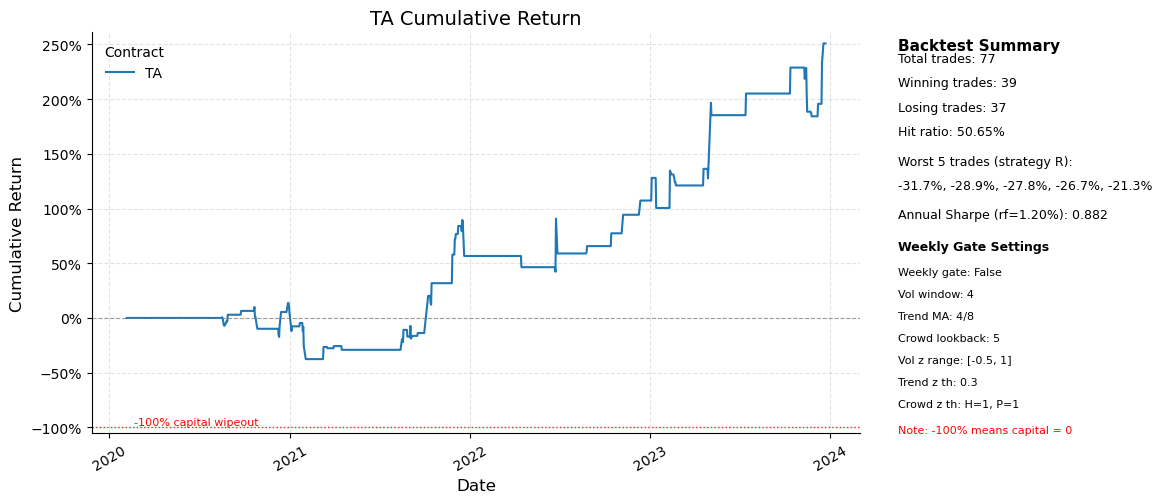

In [69]:
#########################################
# Universal backtest plotting function
# - Displays Weekly Gate settings only
# - Removes WH / Basis filter display
#########################################
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np
import pandas as pd


def plot_backtest(
    bt_df,
    contract_name="Contract",
    save_png=False,
    output_path=None
):
    stats = bt_df.attrs.get("bt_stats", {})

    n_trades   = stats.get("n_trades", np.nan)
    n_win      = stats.get("n_win", np.nan)
    n_loss     = stats.get("n_loss", np.nan)
    win_rate   = stats.get("win_rate", np.nan)
    worst5_ret = stats.get("worst5_loss_ret", [])
    sharpe     = stats.get("sharpe_annual", np.nan)
    rf_annual  = stats.get("rf_annual", 0.012)

    # ===== Weekly gate settings =====
    use_weekly_filter = stats.get("use_weekly_filter", np.nan)

    vol_window       = stats.get("vol_window", np.nan)
    trend_fast       = stats.get("trend_fast", np.nan)
    trend_slow       = stats.get("trend_slow", np.nan)
    crowd_lookback   = stats.get("crowd_lookback", np.nan)

    vol_z_low        = stats.get("vol_z_low", np.nan)
    vol_z_high       = stats.get("vol_z_high", np.nan)
    trend_z_th       = stats.get("trend_z_th", np.nan)
    crowd_hold_z_th  = stats.get("crowd_hold_z_th", np.nan)
    crowd_price_z_th = stats.get("crowd_price_z_th", np.nan)

    win_rate_str = "N/A" if pd.isna(win_rate) else f"{win_rate * 100:.2f}%"
    sharpe_str   = "N/A" if pd.isna(sharpe) else f"{sharpe:.3f}"
    rf_str       = f"{rf_annual * 100:.2f}%"

    worst5_str = (
        ", ".join([f"{x * 100:.1f}%" for x in worst5_ret])
        if len(worst5_ret) > 0 else "N/A"
    )

    def fmt_num(x):
        return "N/A" if pd.isna(x) else f"{x:g}"

    ret = (bt_df["equity"] - 1).dropna()

    fig, ax = plt.subplots(figsize=(12.5, 5.2))
    fig.subplots_adjust(right=0.74)

    ax.plot(ret.index, ret, label=contract_name, linewidth=1.5)

    ax.set_title(f"{contract_name} Cumulative Return", fontsize=14)
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Cumulative Return", fontsize=12)

    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.xticks(rotation=30)

    ax.axhline(0.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.axhline(-1.0, color="red", linestyle=":", linewidth=1.0, alpha=0.85)

    ax.text(
        ret.index[0],
        -1.0,
        "  -100% capital wipeout",
        color="red",
        fontsize=8,
        va="bottom",
        ha="left"
    )

    y_min = min(ret.min(), -1.0)
    y_max = ret.max()
    ax.set_ylim(y_min - 0.05, y_max + 0.10)

    ax.grid(True, linestyle="--", alpha=0.35)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.legend(loc="upper left", frameon=False, title="Contract")

    # ===== Right-side backtest summary =====
    x_stats = 0.77
    y_top   = 0.87
    line_h  = 0.047

    fig.text(x_stats, y_top, "Backtest Summary",
             ha="left", va="top", fontsize=11, fontweight="bold")

    fig.text(x_stats, y_top - 1.0 * line_h,
             f"Total trades: {n_trades}", fontsize=9)

    fig.text(x_stats, y_top - 2.0 * line_h,
             f"Winning trades: {n_win}", fontsize=9)

    fig.text(x_stats, y_top - 3.0 * line_h,
             f"Losing trades: {n_loss}", fontsize=9)

    fig.text(x_stats, y_top - 4.0 * line_h,
             f"Hit ratio: {win_rate_str}", fontsize=9)

    fig.text(x_stats, y_top - 5.2 * line_h,
             "Worst 5 trades (strategy R):", fontsize=9)

    fig.text(x_stats, y_top - 6.2 * line_h,
             worst5_str, fontsize=9)

    fig.text(x_stats, y_top - 7.4 * line_h,
             f"Annual Sharpe (rf={rf_str}): {sharpe_str}", fontsize=9)

    # ===== Weekly Gate settings only =====
    fig.text(x_stats, y_top - 8.7 * line_h,
             "Weekly Gate Settings", fontsize=9, fontweight="bold")

    fig.text(x_stats, y_top - 9.7 * line_h,
             f"Weekly gate: {use_weekly_filter}", fontsize=8)

    fig.text(x_stats, y_top - 10.6 * line_h,
             f"Vol window: {fmt_num(vol_window)}", fontsize=8)

    fig.text(x_stats, y_top - 11.5 * line_h,
             f"Trend MA: {fmt_num(trend_fast)}/{fmt_num(trend_slow)}", fontsize=8)

    fig.text(x_stats, y_top - 12.4 * line_h,
             f"Crowd lookback: {fmt_num(crowd_lookback)}", fontsize=8)

    fig.text(x_stats, y_top - 13.3 * line_h,
             f"Vol z range: [{fmt_num(vol_z_low)}, {fmt_num(vol_z_high)}]",
             fontsize=8)

    fig.text(x_stats, y_top - 14.2 * line_h,
             f"Trend z th: {fmt_num(trend_z_th)}", fontsize=8)

    fig.text(x_stats, y_top - 15.1 * line_h,
             f"Crowd z th: H={fmt_num(crowd_hold_z_th)}, P={fmt_num(crowd_price_z_th)}",
             fontsize=8)

    fig.text(x_stats, y_top - 16.2 * line_h,
             "Note: -100% means capital = 0",
             fontsize=8, color="red")

    if save_png:
        if output_path is None:
            output_path = f"{contract_name}_xgb_w.png"
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to: {output_path}")

    plt.show()


# Example usage
plot_backtest(bt_rm, "TA", save_png=True)